#### Property Prices Prediction for Greek Market Using Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.outliers_influence  import variance_inflation_factor as vfi
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.linear_model import LassoCV, Lasso

In [2]:
df = pd.read_csv("Data/greece_housing_data.csv", encoding='utf-8-sig')

In [3]:
# Checking first 5 rows of DataFrame df
df.head()

,Νομαρχία,Δήμος Καλλικράτη,Δημοτικό ή Κοινοτικό Διαμέρισμα,Ένδειξη ΑΠΑΑ,Κατηγορία Ακινήτου,Πλήθος Προσόψεων,Tιμή Ζώνης,Eπιφάνεια Κύριων Χώρων (σε τ.μ.),Επιφάνεια Βοηθητικών Χώρων (σε τ.μ.),Έτος Κατασκευής,Είδος Εμπράγματου δικαιώματος Κτίσματος,Ποσοστό Συνιδιοκτησίας Κτίσματος,Ειδικές Συνθήκες Ακινήτου,Όροφος,Επιφάνεια Οικοπέδου (σε τ.μ.),Είδος Εμπράγματου δικαιώματος Οικοπέδου,Ποσοστό Συνιδιοκτησίας Οικοπέδου,Συνολική Επιφάνεια Κτισμάτων στο οικόπεδο,Ημερομηνία Συμβολαίου,Τίμημα Δικαιώματος
0,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,1,700.0,35.20,NaN,1966.0,Πλήρης Κυριότητα,100.0,NaN,1,NaN,NaN,NaN,NaN,4/6/2017,7000.0
1,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,1,700.0,63.35,NaN,1975.0,Πλήρης Κυριότητα,100.0,NaN,2,NaN,NaN,NaN,NaN,5/14/2017,18000.0
2,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Αποθήκες / Γεωργικά-Κτηνοτροφικά κτίρια,1,900.0,73.00,NaN,1973.0,Πλήρης Κυριότητα,100.0,NaN,Υ,NaN,NaN,NaN,NaN,6/25/2017,8000.0
3,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,1,900.0,102.00,NaN,1969.0,Πλήρης Κυριότητα,100.0,NaN,1,NaN,NaN,NaN,NaN,7/23/2017,30000.0
4,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,2,900.0,74.50,NaN,1982.0,Πλήρης Κυριότητα,100.0,NaN,1,NaN,NaN,NaN,NaN,7/25/2017,23100.0


In [4]:
# Checking nuumber of rows & columns of the DataFrame 
#304206 rows & 20 columns
df.shape

(304206, 20)

In [5]:
#Checking data types of all Columns
df.dtypes

Νομαρχία                                      object
Δήμος Καλλικράτη                              object
Δημοτικό ή Κοινοτικό Διαμέρισμα               object
Ένδειξη ΑΠΑΑ                                  object
Κατηγορία Ακινήτου                            object
Πλήθος Προσόψεων                               int64
Tιμή Ζώνης                                   float64
Eπιφάνεια Κύριων Χώρων (σε τ.μ.)             float64
Επιφάνεια Βοηθητικών Χώρων (σε τ.μ.)         float64
Έτος Κατασκευής                              float64
Είδος Εμπράγματου δικαιώματος Κτίσματος       object
Ποσοστό Συνιδιοκτησίας Κτίσματος             float64
Ειδικές Συνθήκες Ακινήτου                     object
Όροφος                                        object
Επιφάνεια Οικοπέδου (σε τ.μ.)                float64
Είδος Εμπράγματου δικαιώματος Οικοπέδου       object
Ποσοστό Συνιδιοκτησίας Οικοπέδου             float64
Συνολική Επιφάνεια Κτισμάτων στο οικόπεδο    float64
Ημερομηνία Συμβολαίου                         

In [6]:
#Creating a list for our Columns for Dataframe df
df_columns = list(df)
#Cleaning Columns names in case they had any whitespace not visible
df.columns = df.columns.str.strip()
df_columns

['Νομαρχία',
 'Δήμος Καλλικράτη',
 'Δημοτικό ή Κοινοτικό Διαμέρισμα',
 'Ένδειξη ΑΠΑΑ',
 'Κατηγορία Ακινήτου',
 'Πλήθος Προσόψεων',
 'Tιμή Ζώνης',
 'Eπιφάνεια Κύριων Χώρων (σε τ.μ.)',
 'Επιφάνεια Βοηθητικών Χώρων (σε τ.μ.)',
 'Έτος Κατασκευής',
 'Είδος Εμπράγματου δικαιώματος Κτίσματος',
 'Ποσοστό Συνιδιοκτησίας Κτίσματος',
 'Ειδικές Συνθήκες Ακινήτου',
 'Όροφος',
 'Επιφάνεια Οικοπέδου (σε τ.μ.)',
 'Είδος Εμπράγματου δικαιώματος Οικοπέδου',
 'Ποσοστό Συνιδιοκτησίας Οικοπέδου',
 'Συνολική Επιφάνεια Κτισμάτων στο οικόπεδο',
 'Ημερομηνία Συμβολαίου',
 'Τίμημα Δικαιώματος']

In [7]:
#Renaming Greek column names to shorter English column names
column_mapping = {
    "Νομαρχία": "region",
    "Δήμος Καλλικράτη": "city",
    "Δημοτικό ή Κοινοτικό Διαμέρισμα": "area",
    "Ένδειξη ΑΠΑΑ": "apaa_flag",
    "Κατηγορία Ακινήτου": "property_type",
    "Πλήθος Προσόψεων": "num_facades",
    "Tιμή Ζώνης": "base_price",
    "Eπιφάνεια Κύριων Χώρων (σε τ.μ.)": "main_area_sqm",
    "Επιφάνεια Βοηθητικών Χώρων (σε τ.μ.)": "aux_area_sqm",
    "Έτος Κατασκευής": "year_built",
    "Είδος Εμπράγματου δικαιώματος Κτίσματος": "building_right",
    "Ποσοστό Συνιδιοκτησίας Κτίσματος": "building_share",
    "Ειδικές Συνθήκες Ακινήτου": "conditions",
    "Όροφος": "floor",
    "Επιφάνεια Οικοπέδου (σε τ.μ.)": "land_area",
    "Είδος Εμπράγματου δικαιώματος Οικοπέδου": "land_right",
    "Ποσοστό Συνιδιοκτησίας Οικοπέδου": "land_share",
    "Συνολική Επιφάνεια Κτισμάτων στο οικόπεδο": "total_building_area",
    "Ημερομηνία Συμβολαίου": "contract_year",
    "Τίμημα Δικαιώματος": "price"
}

#Applying the renaming
df = df.rename(columns=column_mapping)
#df.head()

#### Target Column to use from exercise guideline
- Τίμημα Δικαιώματος

In [8]:
target=df['price']
print('The target of our DataFrame is:')
#target

The target of our DataFrame is:


#### Features to use from exercise guideline
- Tιμή Ζώνης
- Eπιφάνεια Κύριων Χώρων (σε τ.μ.)
- Επιφάνεια Βοηθητικών Χώρων (σε τ.μ.)
- Έτος Κατασκευής
- Όροφος
- Κατηγορία Ακινήτου

In [9]:
features=df[['base_price','main_area_sqm','aux_area_sqm','year_built','floor','property_type']]

print('The features of our DataFrame are:')
features

,base_price,main_area_sqm,aux_area_sqm,year_built,floor,property_type
0,700.0,35.20,NaN,1966.0,1,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας
1,700.0,63.35,NaN,1975.0,2,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας
2,900.0,73.00,NaN,1973.0,Υ,Αποθήκες / Γεωργικά-Κτηνοτροφικά κτίρια
3,900.0,102.00,NaN,1969.0,1,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας
4,900.0,74.50,NaN,1982.0,1,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας
...,...,...,...,...,...,...
304201,800.0,NaN,NaN,NaN,NaN,Οικόπεδα
304202,800.0,NaN,NaN,NaN,NaN,Οικόπεδα
304203,590.0,168.00,NaN,1982.0,1,Μονοκατοικία
304204,800.0,NaN,NaN,NaN,NaN,Οικόπεδα


In [10]:
#Checking first 5 rows of our updated DataFrame with name df_final & verifying the column name changes from Greek to English
df.head()

,region,city,area,apaa_flag,property_type,num_facades,base_price,main_area_sqm,aux_area_sqm,year_built,building_right,building_share,conditions,floor,land_area,land_right,land_share,total_building_area,contract_year,price
0,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,1,700.0,35.20,NaN,1966.0,Πλήρης Κυριότητα,100.0,NaN,1,NaN,NaN,NaN,NaN,4/6/2017,7000.0
1,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,1,700.0,63.35,NaN,1975.0,Πλήρης Κυριότητα,100.0,NaN,2,NaN,NaN,NaN,NaN,5/14/2017,18000.0
2,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Αποθήκες / Γεωργικά-Κτηνοτροφικά κτίρια,1,900.0,73.00,NaN,1973.0,Πλήρης Κυριότητα,100.0,NaN,Υ,NaN,NaN,NaN,NaN,6/25/2017,8000.0
3,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,1,900.0,102.00,NaN,1969.0,Πλήρης Κυριότητα,100.0,NaN,1,NaN,NaN,NaN,NaN,7/23/2017,30000.0
4,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,2,900.0,74.50,NaN,1982.0,Πλήρης Κυριότητα,100.0,NaN,1,NaN,NaN,NaN,NaN,7/25/2017,23100.0


In [11]:
#Creating a list of columns for DataFrame
df_columns = list(df)
#print(df_columns)

In [12]:
#Checking main statistics of the DataFrame df_final
df.describe().round(2)

,num_facades,base_price,main_area_sqm,aux_area_sqm,year_built,building_share,land_area,land_share,total_building_area,price
count,304206.00,298459.00,248825.00,56154.00,258355.00,258422.00,94659.00,94649.00,40386.00,3.042060e+05
mean,1.07,1213.34,79.56,29.96,1981.65,85.60,839.80,65.63,249.24,7.683188e+04
std,0.66,597.35,213.31,72.89,22.46,26.05,3314.95,37.24,1821.59,1.434655e+06
min,0.00,122.52,0.10,0.00,1000.00,0.00,0.01,0.00,0.00,0.000000e+00
25%,1.00,900.00,40.00,9.20,1969.00,91.67,200.00,30.08,76.26,9.000000e+03
50%,1.00,1100.00,64.23,13.45,1979.00,100.00,403.60,100.00,125.96,3.000000e+04
75%,1.00,1400.00,90.55,29.25,2001.00,100.00,833.00,100.00,227.35,7.000000e+04
max,7.00,10800.00,47925.20,5593.28,2024.00,100.00,478960.00,100.00,320626.00,6.501000e+08


In [13]:
#Checking for duplicated data in DataFrame df
print('Initial shape is:')
print(df.shape)
#Finding duplicate rows with their non duplicate rows
df[df.duplicated(keep=False)]

#Dropping duplicate data rows found before from DataFrame df
print(df.drop_duplicates(inplace=True))
print('After removing duplicates shape is:')
print(df.shape)
#duplicates were 22.366 rows

#Checking for duplicate rows being fixed
print('Current duplicate rows are:')
print(df.duplicated().sum())

#Reseting index of DataFrame
df.reset_index(drop=True,inplace=True)
df.head()

,region,city,area,apaa_flag,property_type,num_facades,base_price,main_area_sqm,aux_area_sqm,year_built,building_right,building_share,conditions,floor,land_area,land_right,land_share,total_building_area,contract_year,price
0,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,1,700.0,35.20,NaN,1966.0,Πλήρης Κυριότητα,100.0,NaN,1,NaN,NaN,NaN,NaN,4/6/2017,7000.0
1,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,1,700.0,63.35,NaN,1975.0,Πλήρης Κυριότητα,100.0,NaN,2,NaN,NaN,NaN,NaN,5/14/2017,18000.0
2,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Αποθήκες / Γεωργικά-Κτηνοτροφικά κτίρια,1,900.0,73.00,NaN,1973.0,Πλήρης Κυριότητα,100.0,NaN,Υ,NaN,NaN,NaN,NaN,6/25/2017,8000.0
3,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,1,900.0,102.00,NaN,1969.0,Πλήρης Κυριότητα,100.0,NaN,1,NaN,NaN,NaN,NaN,7/23/2017,30000.0
4,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,2,900.0,74.50,NaN,1982.0,Πλήρης Κυριότητα,100.0,NaN,1,NaN,NaN,NaN,NaN,7/25/2017,23100.0


#### Checking initial AS IS correlations between Features & Target Column

In [14]:
#Implementing a correlation Matrix with feature columns & target column
cols = pd.concat([features, target], axis=1)

Correlation_matrix = cols.corr(numeric_only=True).round(3)
Correlation_matrix

,base_price,main_area_sqm,aux_area_sqm,year_built,price
base_price,1.000,-0.021,-0.029,-0.052,0.047
main_area_sqm,-0.021,1.000,0.481,0.017,0.109
aux_area_sqm,-0.029,0.481,1.000,-0.021,0.129
year_built,-0.052,0.017,-0.021,1.000,0.012
price,0.047,0.109,0.129,0.012,1.000


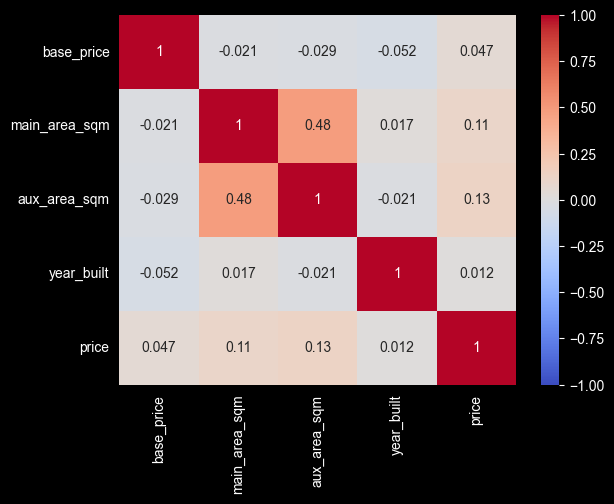

In [15]:
#Creating a Heatmap 
heatmap=sns.heatmap(cols.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, cmap='coolwarm');
heatmap

#### Exploring NaN values in DataFrame

In [16]:
#Checking for existance of null values -> We have nulls to handle
df_NaN = df.isna().sum()
print(' ')
print('The analysis for NaN values is:')
print(df_NaN)

 
The analysis for NaN values is:
region                      0
city                        0
area                        0
apaa_flag                   0
property_type               0
num_facades                 0
base_price               5350
main_area_sqm           50421
aux_area_sqm           230003
year_built              42111
building_right          43130
building_share          42047
conditions             267899
floor                   42007
land_area              194289
land_right             194441
land_share             194300
total_building_area    244374
contract_year               0
price                       0
dtype: int64


#### Exploring Feature Column floor

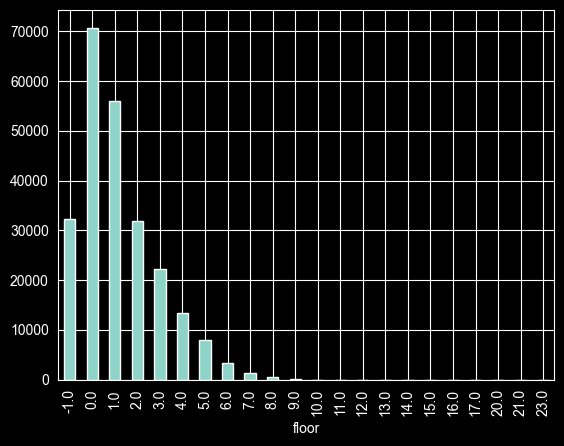

In [17]:
#Understanding values in Column floor
unique_floor_count = df['floor'].nunique()
print('The unique values in Feature Column floor are:',unique_floor_count)
print(' ')

print(df['floor'].value_counts())
print(' ')

#Fixing values for floor for basement to be -1, instead of 'Υ' by replacing the string
df['floor'] = df['floor'].str.replace('Υ', '-1')

# Converting the column to numeric
df['floor'] = pd.to_numeric(df['floor'])

#Checking values have been updated correctly
print('The updated values of Column floor are:')
print(df['floor'].value_counts().sort_index())
print(' ')

#Checking updated statistics of Column floor
df['floor'].describe().round(2)

#Visualizing column floor per values
#With the plot.bar we see that we have outliers
df['floor'].value_counts().sort_index().plot.bar()

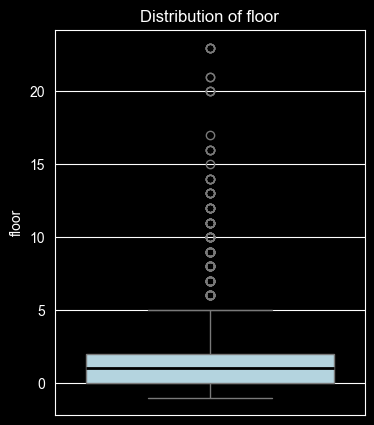

In [18]:
#Checking more thoroughly for Outliers of column floor
plt.figure(figsize=(4,5))
sns.boxplot(y=df['floor'], medianprops={'color': 'black', 'linewidth': 2}, color='lightblue')
plt.title('Distribution of floor')
plt.ylabel('floor')
plt.show()

In [19]:
#Finding the index of rows where Feature column floor is NaN.
NaN_rows_floor = df[df['floor'].isna()].index
print(' ')
print(f"Total rows in DataFrame should be 304206. The NaN values in column floor are: {df['floor'].isna().sum()}")
nan_percentage_floor = (df['floor'].isna().sum() / len(df)) * 100
print(f"This represents {nan_percentage_floor:.2f}% of the total rows in the DataFrame.")
print(' ')
#df[df['floor'].isna()]

 
Total rows in DataFrame should be 304206. The NaN values in column floor are: 42007
This represents 14.90% of the total rows in the DataFrame.
 


In [20]:
#Filling NaN value rows of Column Floor with the median of the Column floor
floor_median = df['floor'].median()
print(f"Filling missing values with Median: {floor_median}")

# Filling NaNs of Column floor
df['floor'] = df['floor'].fillna(floor_median)

#Checking we no longer have NaNs in Column floor
print(f"Remaining NaNs: {df['floor'].isna().sum()}")

Filling missing values with Median: 1.0
Remaining NaNs: 0


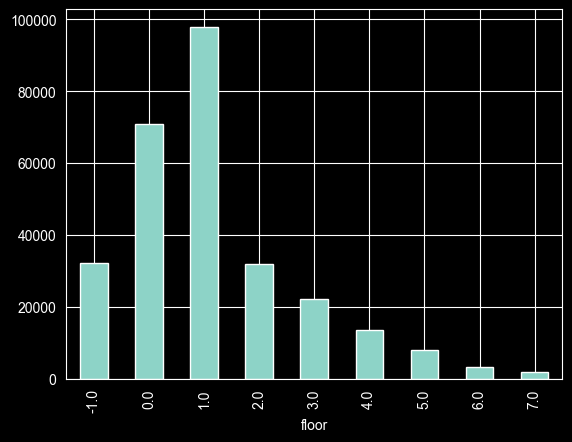

In [21]:
#Fixing outliers of floor Column by turning them into 7
df.loc[df['floor'] > 7, 'floor'] = 7
print(df['floor'].value_counts().sort_index())
df['floor'].value_counts().sort_index().plot.bar()

#### Exploring Feature Column base_price 

In [22]:
#Understanding values in Column base_price
unique_base_price_count = df['base_price'].nunique()
print('The unique values in Feature Column base_price are:',unique_base_price_count)
print(' ')

#Checking statistics of Column base_price
print(df['base_price'].describe().round(2))
print(' ')

print(df['base_price'].value_counts())
print(' ')

The unique values in Feature Column base_price are: 175
 
count    276490.00
mean       1212.11
std         597.27
min         122.52
25%         900.00
50%        1100.00
75%        1400.00
max       10800.00
Name: base_price, dtype: float64
 
base_price
1250.00    17285
1100.00    15758
1050.00    14404
900.00     14175
950.00     13744
           ...  
870.00         1
210.00         1
122.52         1
1060.00        1
3400.00        1
Name: count, Length: 175, dtype: int64
 


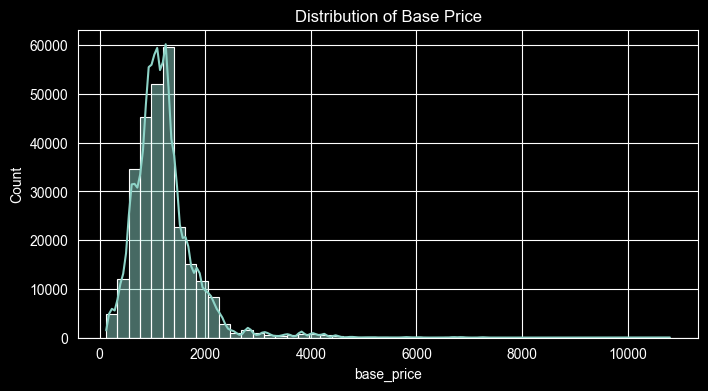

In [23]:
#Checking more thoroughly for Outliers of column base_price
plt.figure(figsize=(8, 4))
# Using kde=True to add the smooth line
sns.histplot(df['base_price'], kde=True, bins=50) 
plt.title('Distribution of Base Price')
plt.show()

In [24]:
#Finding the index of rows where Feature column base_price is NaN.
NaN_rows_base_price = df[df['base_price'].isna()].index
print(' ')
print(f"Total rows in DataFrame should be 304206. The NaN values in column base_price are: {df['base_price'].isna().sum()}")
nan_percentage_base_price = (df['base_price'].isna().sum() / len(df)) * 100
print(f"This represents {nan_percentage_base_price:.2f}% of the total rows in the DataFrame.")
print(' ')
#df[df['base_price'].isna()]

 
Total rows in DataFrame should be 304206. The NaN values in column base_price are: 5350
This represents 1.90% of the total rows in the DataFrame.
 


In [25]:
# Filling NaNs value rows of Column base_price
# Initially filling NaNs using the median of the specific area
df['base_price'] = df['base_price'].fillna(
    df.groupby('area')['base_price'].transform('median'))

# If there are still NaN ( whole column area had no base prices), filling using the city median
df['base_price'] = df['base_price'].fillna(
    df.groupby('city')['base_price'].transform('median'))

# If still NaN ( whole columns area & city had no base prices) , filling using the region median
df['base_price'] = df['base_price'].fillna(
    df.groupby('region')['base_price'].transform('median'))

# else filling any remaining NaNs with the column base_price median
df['base_price'] = df['base_price'].fillna(df['base_price'].median())

#Checking we no longer have NaNs in Column base_price
print(f"Remaining NaNs: {df['base_price'].isna().sum()}")
print(' ')

# Checking updated statistics of Column base_price
print(df['base_price'].describe().round(2))

Remaining NaNs: 0
 
count    281840.00
mean       1202.40
std         596.96
min         122.52
25%         850.00
50%        1100.00
75%        1400.00
max       10800.00
Name: base_price, dtype: float64


In [26]:
#Creating a list for all values of column base_price
base_price = df['base_price'].to_list()

#Splitting base_price values in percentiles 
Q1 = np.percentile(base_price,25,method='midpoint')
Q2 = np.percentile(base_price,50,method='midpoint')
Q3 = np.percentile(base_price,75,method='midpoint')

#Calculating the Interquartile Range
IQR=Q3-Q1

print('base_price Outliers are:')
print('Minimum:', Q1 - 1.5 * IQR)  #lower outlier fence
print('Maximum:', Q3 + 1.5 * IQR)  #maximum outlier fence

base_price Outliers are:
Minimum: 25.0
Maximum: 2225.0


In [27]:
#Filling outliers list with values that are considered above max base_price  values & below min base_price  values
#expected to see all values thus >2150 and <150.0  
outliers_base_price  = []
for i in base_price:
    if (i>Q3 + 1.5 * IQR) or (i< Q1 - 1.5 * IQR):
        outliers_base_price.append(i)
#outliers_base_price

In [28]:
#Finding rows with outliers values in column base_price
df[df['base_price'].isin(outliers_base_price)]

#Assigning rows with outliers values in column base_price to DataFrame outliers_df
outliers_df=df[df['base_price'].isin(outliers_base_price)]
outliers_df

,region,city,area,apaa_flag,property_type,num_facades,base_price,main_area_sqm,aux_area_sqm,year_built,building_right,building_share,conditions,floor,land_area,land_right,land_share,total_building_area,contract_year,price
328,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΘΗΝΑΙΩΝ,ΑΘΗΝΑΙΩΝ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,1,2250.0,140.00,NaN,1935.0,Πλήρης Κυριότητα,100.0,NaN,3.0,NaN,NaN,NaN,NaN,2/28/2017,150000.0
341,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΘΗΝΑΙΩΝ,ΑΘΗΝΑΙΩΝ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,1,5800.0,160.00,NaN,1961.0,Πλήρης Κυριότητα,50.0,NaN,7.0,NaN,NaN,NaN,NaN,3/1/2017,400000.0
399,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΘΗΝΑΙΩΝ,ΑΘΗΝΑΙΩΝ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,1,4000.0,132.00,6.00,1961.0,Πλήρης Κυριότητα,100.0,NaN,2.0,NaN,NaN,NaN,NaN,3/13/2017,300000.0
403,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΘΗΝΑΙΩΝ,ΑΘΗΝΑΙΩΝ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,2,2800.0,216.11,5.00,1951.0,Πλήρης Κυριότητα,100.0,NaN,4.0,NaN,NaN,NaN,NaN,3/13/2017,150000.0
405,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΘΗΝΑΙΩΝ,ΑΘΗΝΑΙΩΝ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,1,4000.0,112.80,NaN,1963.0,Πλήρης Κυριότητα,25.0,NaN,2.0,NaN,NaN,NaN,NaN,3/14/2017,68750.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279050,ΠΕΙΡΑΙΩΣ (ΝΟΜΑΡΧΙΑ),ΣΠΕΤΣΩΝ,ΣΠΕΤΣΩΝ,Εντός ΑΠΑΑ,Μονοκατοικία,1,4350.0,36.22,24.21,1975.0,Πλήρης Κυριότητα,100.0,NaN,1.0,440.61,Πλήρης Κυριότητα,100.0,60.43,9/28/2025,7500000.0
279060,ΠΕΙΡΑΙΩΣ (ΝΟΜΑΡΧΙΑ),ΥΔΡΑΣ,ΥΔΡΑΣ,Εντός ΑΠΑΑ,Μονοκατοικία,2,3300.0,151.04,42.35,2005.0,Πλήρης Κυριότητα,100.0,NaN,1.0,252.87,Πλήρης Κυριότητα,100.0,204.60,2/25/2025,500000.0
279061,ΠΕΙΡΑΙΩΣ (ΝΟΜΑΡΧΙΑ),ΥΔΡΑΣ,ΥΔΡΑΣ,Εντός ΑΠΑΑ,Μονοκατοικία,1,3350.0,96.95,NaN,1955.0,Πλήρης Κυριότητα,100.0,NaN,1.0,64.78,Πλήρης Κυριότητα,100.0,96.95,3/28/2025,530000.0
279065,ΠΕΙΡΑΙΩΣ (ΝΟΜΑΡΧΙΑ),ΥΔΡΑΣ,ΥΔΡΑΣ,Εντός ΑΠΑΑ,Μονοκατοικία,3,3350.0,208.22,NaN,1900.0,Πλήρης Κυριότητα,100.0,NaN,1.0,282.08,Πλήρης Κυριότητα,100.0,208.22,5/20/2025,280000.0


In [29]:
#Counting rows with outliers values in column base_price
num_outliers = outliers_df.shape[0]
num_outliers

11559

In [30]:
#With IQR method we appear to have too many outliers (13056) therefore, we do not choose to use it as removing them
#would mean a loss of several rows

In [31]:
# Trying Quantile Binning method to group data to 5 tiers
# groups/tiers (Quintiles): Very Low, Low, Medium, High, Very High
group_names = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df['base_price_tier'] = pd.qcut(df['base_price'], q=5, labels=group_names)

print(df.groupby('base_price_tier', observed=True)['base_price'].agg(['min', 'max', 'count']))

                     min      max  count
base_price_tier                         
Very Low          122.52    800.0  64136
Low               810.00   1000.0  49111
Medium           1020.00   1250.0  70828
High             1260.00   1500.0  43111
Very High        1550.00  10800.0  54654


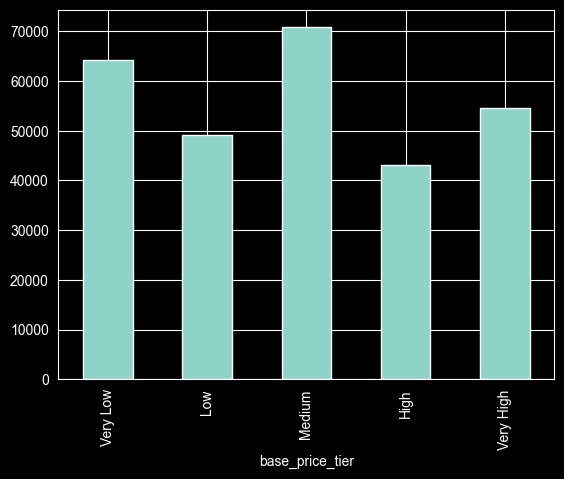

In [32]:
#Checking visualization of values for Column price_tier
print(df['base_price_tier'].value_counts())
df['base_price_tier'].value_counts().sort_index().plot.bar()
plt.show()

In [33]:
#Implementing Log Transformation to column base_price in a new Column log_base_price
df['log_base_price'] = np.log(df['base_price'])

#Checking Statistics for Column log_base_price
print(df['log_base_price'].describe().round(2))

#Visualizing the Before vs After the Log Transformation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plotting before Log Transformation base_price
sns.histplot(df['base_price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Before: Log Transformed')

# Plotting after Log Transformation base_price
sns.histplot(df['log_base_price'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('After: Log Transformed')
plt.show()

# Checking the new skewness (It should be closer to 0)
print("Original Skewness:", df['base_price'].skew().round(2))
print("Transformed Skewness:", df['log_base_price'].skew().round(2))

Original Skewness: 2.56
Transformed Skewness: -0.45


In [34]:
#Implementing IQR method now for Column log_base_price 
log_base_price = df['log_base_price']

#Splitting base_price values in percentiles 
Q1 = np.percentile(log_base_price,25,method='midpoint')
Q2 = np.percentile(log_base_price,50,method='midpoint')
Q3 = np.percentile(log_base_price,75,method='midpoint')

#Calculating the Interquartile Range
IQR=Q3-Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print('log_base_price Outliers are:')
print(f"Lower Fence (Log): {lower_fence}")
print(f"Upper Fence (Log): {upper_fence}")

log_base_price Outliers are:
Lower Fence (Log): 5.996749600305882
Upper Fence (Log): 7.992714264781831


In [35]:
#Finding rows with outliers values in column log_base_price
outliers_log_base_price_df = df[(df['log_base_price'] < lower_fence) | (df['log_base_price'] > upper_fence)]
print("Number of outliers found:", outliers_log_base_price_df.shape[0])
print(' ')

#Checking outlies of log_base_price rows
#outliers_log_base_price_df

Number of outliers found: 13447
 


In [36]:
#Still after the log Transformation we have too many Outliers with IQR method.
#Adjusting IQR fences to find the extreme outliers

log_base_price = df['log_base_price']

#Splitting base_price values in percentiles 
Q1 = np.percentile(log_base_price,25,method='midpoint')
Q2 = np.percentile(log_base_price,50,method='midpoint')
Q3 = np.percentile(log_base_price,75,method='midpoint')

#Adjusting fences to capture (with 3.0 * IQR ) ~99.99% of a normal distribution and not the 99.3% (with 1.5 * IQR). 
#Anything flagged by this is truly mathematically bizarre and we will treat it as an extreme Outlier
IQR=Q3-Q1

lower_fence_extreme = Q1 - 3 * IQR
upper_fence_extreme = Q3 + 3 * IQR

print('log_base_price Extreme Outliers are:')
print(f"Lower Fence Extreme(Log): {lower_fence_extreme}")
print(f"Upper Fence Extreme(Log): {upper_fence_extreme}")

log_base_price Extreme Outliers are:
Lower Fence Extreme(Log): 5.248262851127401
Upper Fence Extreme(Log): 8.74120101396031


In [37]:
#Finding rows with extreme outliers values in column log_base_price
outliers_log_base_price_extreme_df = df[(df['log_base_price'] < lower_fence_extreme) | (df['log_base_price'] > upper_fence_extreme)]
print("Number of outliers found:", outliers_log_base_price_extreme_df.shape[0])
print(' ')
#outliers_log_base_price_extreme_df

#Organizing outlier data so i can understand if the values found as extreme outliers make sense.
#print(outliers_log_base_price_extreme_df[['base_price', 'log_base_price']].sort_values(by='base_price'))

print('Initial DataFrame shape before removal of Extreme Outliers in column log_base_price:')
print(df.shape)
print(' ')

#Dropping rows with extreme outliers spotted in column log_base_price by their index
df = df.drop(outliers_log_base_price_extreme_df.index)

print('Updated DataFrame shape after removal of Extreme Outliers in column log_base_price:')
print(df.shape)
print(' ')

#Reseting index of DataFrame
df.reset_index(drop=True,inplace=True)
df.head()

,region,city,area,apaa_flag,property_type,num_facades,base_price,main_area_sqm,aux_area_sqm,year_built,...,conditions,floor,land_area,land_right,land_share,total_building_area,contract_year,price,base_price_tier,log_base_price
0,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,1,700.0,35.20,NaN,1966.0,...,NaN,1.0,NaN,NaN,NaN,NaN,4/6/2017,7000.0,Very Low,6.551080
1,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,1,700.0,63.35,NaN,1975.0,...,NaN,2.0,NaN,NaN,NaN,NaN,5/14/2017,18000.0,Very Low,6.551080
2,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Αποθήκες / Γεωργικά-Κτηνοτροφικά κτίρια,1,900.0,73.00,NaN,1973.0,...,NaN,-1.0,NaN,NaN,NaN,NaN,6/25/2017,8000.0,Low,6.802395
3,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,1,900.0,102.00,NaN,1969.0,...,NaN,1.0,NaN,NaN,NaN,NaN,7/23/2017,30000.0,Low,6.802395
4,ΑΘΗΝΩΝ (ΝΟΜΑΡΧΙΑ),ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ,Εντός ΑΠΑΑ,Κατοικία ή διαμέρισμα πλήν μονοκατοικίας,2,900.0,74.50,NaN,1982.0,...,NaN,1.0,NaN,NaN,NaN,NaN,7/25/2017,23100.0,Low,6.802395


In [38]:
#Checking again Statistics for Column log_base_price
print(df['log_base_price'].describe().round(2))

#Visualizing the Before vs After the Log Transformation & removal of Extreme Outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plotting before Log Transformation base_price
sns.histplot(df['base_price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Before: Log Transformed & Removal of Extreme Outliers')

# Plotting after Log Transformation base_price
sns.histplot(df['log_base_price'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('After: Log Transformed & Removal of Extreme Outliers')
plt.show()

# Checking the new skewness (It should be closer to 0)
print("Original Skewness:", df['base_price'].skew().round(2))
print("Transformed Skewness:", df['log_base_price'].skew().round(2))

Original Skewness: 2.02
Transformed Skewness: -0.49


#### Exploring Feature Column property_type

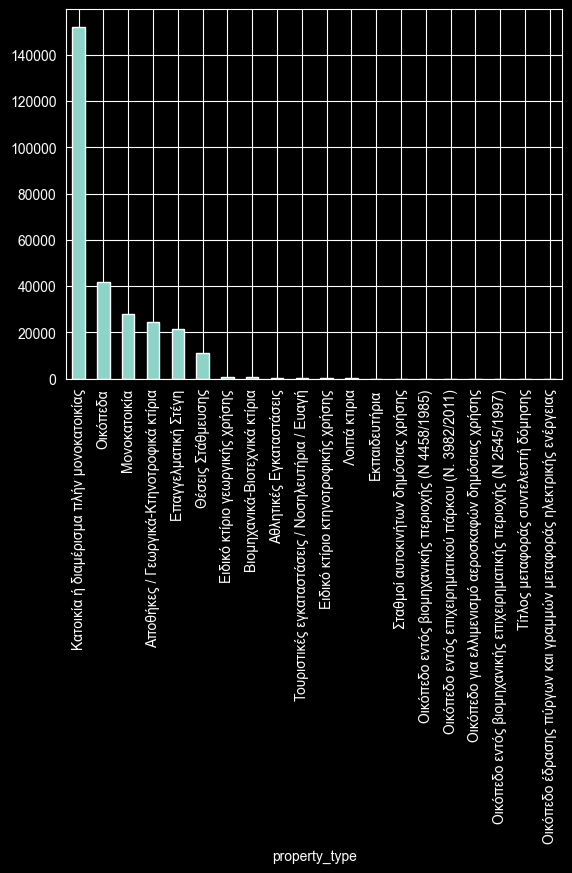

In [39]:
#Understanding values in Column property_type
unique_property_type_count = df['property_type'].nunique()
print('The unique values in Feature Column property_type are:',unique_property_type_count)
print(' ')

#Checking statistics of Column base_price
print(df['property_type'].describe())
print(' ')

print(df['property_type'].value_counts())
print(' ')
df['property_type'].value_counts().plot.bar();
plt.show()
#From plot.bar we understand we have some categories with very little contribution

In [40]:
#Finding the index of rows where Feature column property_type is NaN.
NaN_rows_property_type = df[df['property_type'].isna()].index
print(' ')
print(f"Total rows in DataFrame should be 304206. The NaN values in column property_type are: {df['property_type'].isna().sum()}")
nan_percentage_property_type = (df['property_type'].isna().sum() / len(df)) * 100
print(f"This represents {nan_percentage_property_type:.2f}% of the total rows in the DataFrame.")
print(' ')
#df[df['property_type'].isna()]

 
Total rows in DataFrame should be 304206. The NaN values in column property_type are: 0
This represents 0.00% of the total rows in the DataFrame.
 


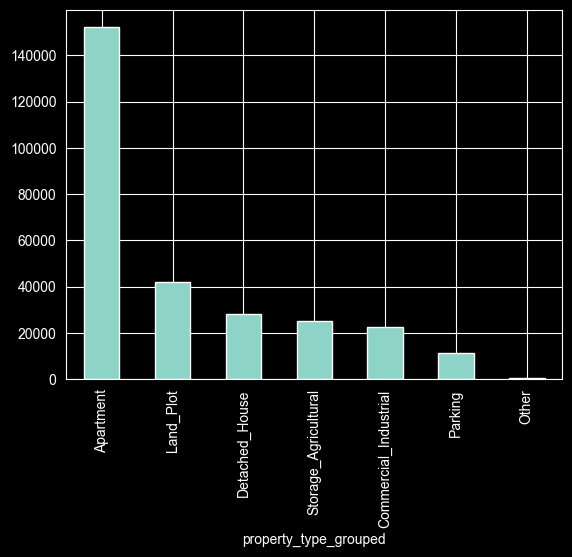

In [41]:
#Grouping values for property_type Column in new Column with name property_type_grouped

def grouping_property_type_values(x):
    # 1. Grouping property_type values for 'Residential' 
    if x == 'Κατοικία ή διαμέρισμα πλήν μονοκατοικίας':
        return 'Apartment'
    elif x == 'Μονοκατοικία':
        return 'Detached_House'
    
    # 2. Grouping property_type values for land 
    elif 'Οικόπεδ' in x or 'Τίτλος' in x:
        return 'Land_Plot'
    
    # 3. Grouping property_type values for commercial/income-generating properties
    elif x in ['Επαγγελματική Στέγη', 
               'Τουριστικές εγκαταστάσεις / Νοσηλευτήρια / Ευαγή', 
               'Σταθμοί αυτοκινήτων δημόσιας χρήσης',
               'Βιομηχανικά-Βιοτεχνικά κτίρια']:
        return 'Commercial_Industrial'
        
    # 4. Grouping property_type values for storage & agricultural
    elif 'Αποθήκες' in x or 'γεωργικής' in x or 'κτηνοτροφικής' in x:
        return 'Storage_Agricultural'
        
    # 5. Grouping property_type values for parking
    elif x == 'Θέσεις Στάθμευσης':
        return 'Parking'
        
    # 6. Grouping property_type values for the Other bucket
    else:
        return 'Other'

# Applying the transformation
df['property_type_grouped'] = df['property_type'].apply(grouping_property_type_values)

#Checking the new distribution of new column property_type_engineered
print(df['property_type_grouped'].value_counts())
print(' ')

df['property_type_grouped'].value_counts().plot.bar();
plt.show()

#### Exploring Feature Column year_built

In [42]:
#Understanding values in Column year_built
unique_year_built_count = df['year_built'].nunique()
print('The unique values in Feature Column year_built are:',unique_year_built_count)
print(' ')

#Checking statistics of Column base_price
print(df['year_built'].describe())
print(' ')

print(df['year_built'].value_counts())
print(' ')

The unique values in Feature Column year_built are: 226
 
count    239608.000000
mean       1981.498368
std          22.580651
min        1000.000000
25%        1969.000000
50%        1979.000000
75%        2001.000000
max        2024.000000
Name: year_built, dtype: float64
 
year_built
2011.0    11274
1975.0    10100
2003.0     8041
1982.0     7713
2005.0     7337
          ...  
1790.0        1
1841.0        1
1509.0        1
1000.0        1
1878.0        1
Name: count, Length: 226, dtype: int64
 


In [43]:
#Finding the index of rows where Feature column year_built is NaN.
NaN_rows_year_built = df[df['year_built'].isna()].index
print(' ')
print(f"Total rows in DataFrame should be 304206. The NaN values in column year_built are: {df['year_built'].isna().sum()}")
nan_percentage_year_built = (df['year_built'].isna().sum() / len(df)) * 100
print(f"This represents {nan_percentage_year_built:.2f}% of the total rows in the DataFrame.")
print(' ')
#df[df['year_built'].isna()]

 
Total rows in DataFrame should be 304206. The NaN values in column year_built are: 42059
This represents 14.93% of the total rows in the DataFrame.
 


In [44]:
#Filling NaN value rows of Column year_built with the median of the Column year_built
year_built_median = df['year_built'].median()
print(f"Filling missing values with Median: {year_built_median}")

# Filling NaNs of Column year_built
df['year_built'] = df['year_built'].fillna(year_built_median)

#Checking we no longer have NaNs in Column year_built
print(f"Remaining NaNs: {df['year_built'].isna().sum()}")

Filling missing values with Median: 1979.0
Remaining NaNs: 0


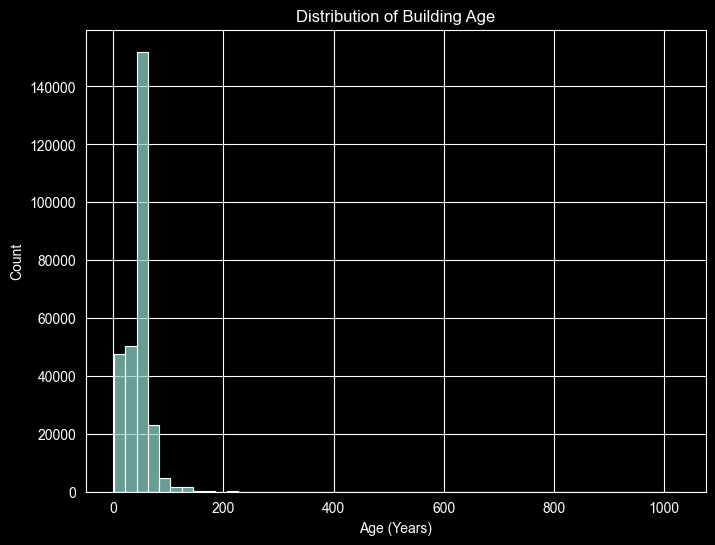

In [45]:
# Calculating building_age of the property (current year is 2025)
df['building_age'] = 2025 - df['year_built']
print(df['building_age'].value_counts())

plt.figure(figsize=(8, 6))
sns.histplot(df['building_age'], bins=50)
plt.title('Distribution of Building Age')
plt.xlabel('Age (Years)')
plt.ylabel('Count')
plt.show()

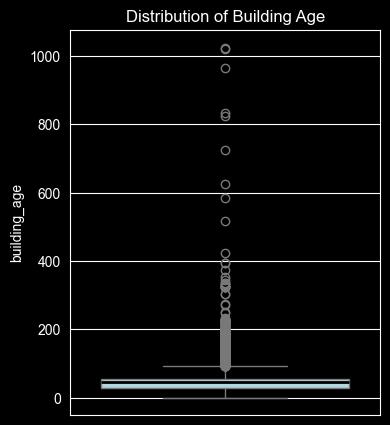

In [46]:
#Checking more thoroughly for Outliers of column building_age
plt.figure(figsize=(4,5))
sns.boxplot(y=df['building_age'], medianprops={'color': 'black', 'linewidth': 2}, color='lightblue')
plt.title('Distribution of Building Age')
plt.ylabel('building_age')

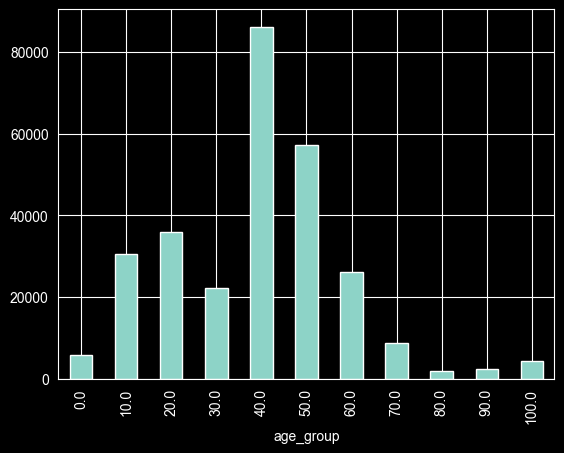

In [47]:
#Turning outliers of building_age into 100
df.loc[df['building_age'] > 100, 'building_age'] = 100
df['age_group'] = (df['building_age'] // 10) * 10
print(df['age_group'].value_counts().sort_index())
df['age_group'].value_counts().sort_index().plot.bar()

#### Exploring Feature Column main_area_sqm

In [48]:
#Understanding values in Column main_area_sqm
unique_main_area_sqm_count = df['main_area_sqm'].nunique()
print('The unique values in Feature Column main_area_sqm are:',unique_main_area_sqm_count)
print(' ')

#Checking statistics of Column main_area_sqm
print(df['main_area_sqm'].describe())
print(' ')

print(df['main_area_sqm'].value_counts())
print(' ')

The unique values in Feature Column main_area_sqm are: 22253
 
count    231302.000000
mean         79.917170
std         219.679424
min           0.100000
25%          40.320000
50%          64.370000
75%          90.500000
max       47925.200000
Name: main_area_sqm, dtype: float64
 
main_area_sqm
50.00      2392
70.00      1613
80.00      1332
60.00      1320
52.00      1302
           ... 
415.72        1
2264.90       1
175.76        1
220.85        1
168.42        1
Name: count, Length: 22253, dtype: int64
 


In [49]:
#Finding the index of rows where Feature column main_area_sqm is NaN.
NaN_rows_main_area_sqm = df[df['main_area_sqm'].isna()].index
print(' ')
print(f"Total rows in DataFrame should be 304206. The NaN values in column main_area_sqm are: {df['main_area_sqm'].isna().sum()}")
nan_percentage_main_area_sqm = (df['main_area_sqm'].isna().sum() / len(df)) * 100
print(f"This represents {nan_percentage_main_area_sqm:.2f}% of the total rows in the DataFrame.")
print(' ')
#df[df['main_area_sqm'].isna()]

 
Total rows in DataFrame should be 304206. The NaN values in column main_area_sqm are: 50365
This represents 17.88% of the total rows in the DataFrame.
 


In [50]:
#Filling NaN value rows of Column main_area_sqm 
#----------------------------------------------
# Filling NaNs using the median area of the same Property Type within the specific City
df['main_area_sqm'] = df['main_area_sqm'].fillna(
    df.groupby(['property_type', 'city'])['main_area_sqm'].transform('median'))

# If remaining NaNs, filling with the national median for that Property Type.
df['main_area_sqm'] = df['main_area_sqm'].fillna(
    df.groupby('property_type')['main_area_sqm'].transform('median'))

# If remaining NaNs as property type is unique and has no data anywhere, using the median of main_area_sqm.
df['main_area_sqm'] = df['main_area_sqm'].fillna(df['main_area_sqm'].median())

#Checking we no longer have NaNs in Column main_area_sqm
print(f"Remaining NaNs: {df['main_area_sqm'].isna().sum()}")

#Checking updated statistics of Column main_area_sqm
print(df['main_area_sqm'].describe())

Remaining NaNs: 0
count    281667.000000
mean         75.349481
std         199.478680
min           0.100000
25%          43.000000
50%          62.380000
75%          83.680000
max       47925.200000
Name: main_area_sqm, dtype: float64


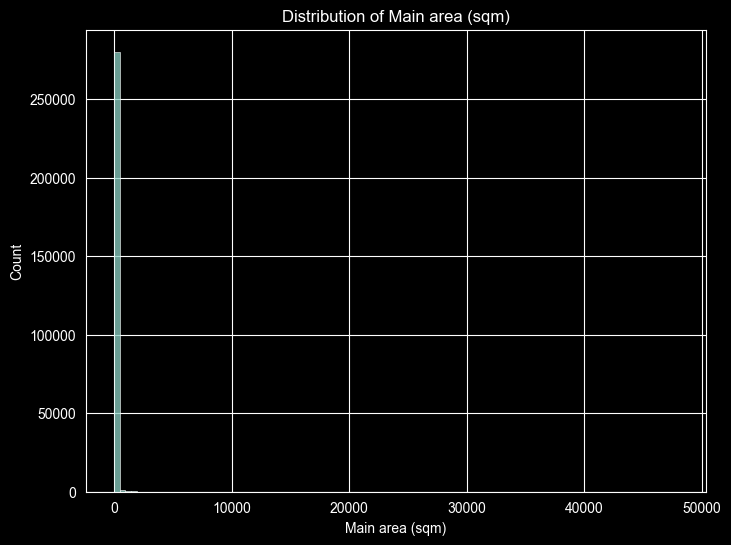

In [51]:
#Checking distribution of Column main_area_sqm
#Right skewed Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['main_area_sqm'], bins=100)
plt.title('Distribution of Main area (sqm)')
plt.xlabel('Main area (sqm)')
plt.ylabel('Count')
plt.show()

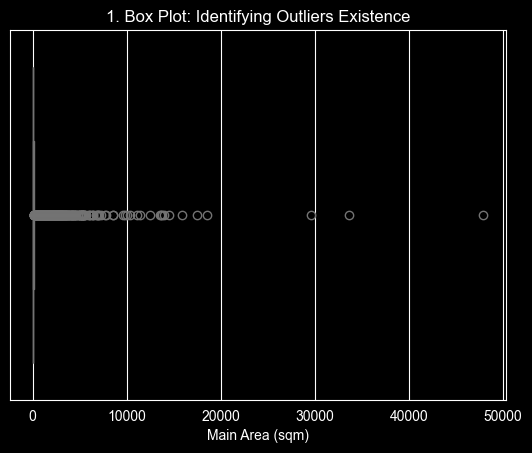

In [52]:
#Checking for Outliers Existance in Column main_area_sqm
sns.boxplot(x=df['main_area_sqm'], color='lightgreen')
plt.title('1. Box Plot: Identifying Outliers Existence')
plt.xlabel('Main Area (sqm)')
plt.show()

In [53]:
#Implementing Log Transformation to column main_area_sqm in a new Column log_main_area_sqm
df['log_main_area_sqm'] = np.log(df['main_area_sqm'])

#Checking Statistics for Column log_main_area_sqm
print(df['log_main_area_sqm'].describe().round(2))

#Visualizing the Before vs After the Log Transformation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plotting before Log Transformation main_area_sqm
sns.histplot(df['main_area_sqm'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Before: Log Transformed')

# Plotting after Log Transformation main_area_sqm
sns.histplot(df['log_main_area_sqm'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('After: Log Transformed')
plt.show()

# Checking the new skewness (It should be closer to 0)
print("Original Skewness:", df['main_area_sqm'].skew().round(2))
print("Transformed Skewness:", df['log_main_area_sqm'].skew().round(2))

Original Skewness: 100.28
Transformed Skewness: -0.77


In [54]:
#Implementing IQR for Column log_main_area_sqm to detect Outliers
log_main_area_sqm = df['log_main_area_sqm']

#Splitting base_price values in percentiles 
Q1 = np.percentile(log_main_area_sqm,25,method='midpoint')
Q2 = np.percentile(log_main_area_sqm,50,method='midpoint')
Q3 = np.percentile(log_main_area_sqm,75,method='midpoint')

#Calculating the Interquartile Range
IQR=Q3-Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print('Column log_main_area_sqm Outliers are:')
print(f"Lower Fence (Log): {lower_fence}")
print(f"Upper Fence (Log): {upper_fence}")

Column log_main_area_sqm Outliers are:
Lower Fence (Log): 2.7625002887589867
Upper Fence (Log): 5.425699827251189


In [55]:
#Finding rows with outliers values in column log_main_area_sqm
outliers_log_main_area_sqm_df = df[(df['log_main_area_sqm'] < lower_fence) | (df['log_main_area_sqm'] > upper_fence)]
print("Number of outliers found:", outliers_log_main_area_sqm_df.shape[0])
print(' ')

#Checking outliers of log_main_area_sqm rows
#outliers_log_main_area_sqm_df

Number of outliers found: 32226
 


In [56]:
#Still after the log Transformation we have too many Outliers with IQR method, which is logical as we are referring to sqm.
#Adjusting IQR fences to find extreme outliers.
log_main_area_sqm = df['log_main_area_sqm']

#Splitting base_price values in percentiles 
Q1 = np.percentile(log_main_area_sqm,25,method='midpoint')
Q2 = np.percentile(log_main_area_sqm,50,method='midpoint')
Q3 = np.percentile(log_main_area_sqm,75,method='midpoint')

#Adjusting fences to capture (with 3.0 * IQR ) ~99.99% of a normal distribution and not the 99.3% (with 1.5 * IQR). 
#Anything flagged by this is truly mathematically bizarre and we will treat it as an extreme Outlier
IQR=Q3-Q1

lower_fence_extreme = Q1 - 3 * IQR
upper_fence_extreme = Q3 + 3 * IQR

print('Column log_main_area_sqm Extreme Outliers are:')
print(f"Lower Fence Extreme(Log): {lower_fence_extreme}")
print(f"Upper Fence Extreme(Log): {upper_fence_extreme}")

Column log_main_area_sqm Extreme Outliers are:
Lower Fence Extreme(Log): 1.7638004618244105
Upper Fence Extreme(Log): 6.424399654185764


In [57]:
#Finding rows with extreme outliers values in column log_main_area_sqm
outliers_log_main_area_sqm_extreme_df = df[(df['log_main_area_sqm'] < lower_fence_extreme) | (df['log_main_area_sqm'] > upper_fence_extreme)]
print("Number of outliers found:", outliers_log_main_area_sqm_extreme_df.shape[0])
print(' ')
#outliers_log_main_area_sqm_extreme_df

#Organizing outlier data so i can understand if the values found as extreme outliers make sense.
#print(outliers_log_main_area_sqm_extreme_df[['main_area_sqm', 'log_main_area_sqm']].sort_values(by='main_area_sqm'))

print('Initial DataFrame shape before removal of Extreme Outliers in column log_main_area_sqm:')
print(df.shape)
print(' ')

#Dropping rows with extreme outliers spotted in column log_main_area_sqm by their index
df = df.drop(outliers_log_main_area_sqm_extreme_df.index)

print('Updated DataFrame shape after removal of Extreme Outliers in column log_main_area_sqm:')
print(df.shape)
print(' ')

#Reseting index of DataFrame
df.reset_index(drop=True,inplace=True)
#df.head()

Updated DataFrame shape after removal of Extreme Outliers in column log_main_area_sqm:
(276052, 26)
 


In [58]:
#Checking again Statistics for Column log_main_area_sqm
print(df['log_main_area_sqm'].describe().round(2))

#Visualizing the Before vs After the Log Transformation & removal of Extreme Outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Plotting before Log Transformation main_area_sqm
sns.histplot(df['main_area_sqm'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Before: Log Transformed & Removal of Extreme Outliers')

# Plotting after Log Transformation main_area_sqm
sns.histplot(df['log_main_area_sqm'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('After: Log Transformed & Removal of Extreme Outliers')
plt.show()

# Checking the new skewness (It should be closer to 0)
print("Original Skewness:", df['main_area_sqm'].skew().round(2))
print("Transformed Skewness:", df['log_main_area_sqm'].skew().round(2))

Original Skewness: 3.37
Transformed Skewness: -0.8


#### Exploring Feature Column aux_area_sqm

In [59]:
#Understanding values in Column aux_area_sqm
unique_aux_area_sqm_count = df['aux_area_sqm'].nunique()
print('The unique values in Feature Column aux_area_sqm are:',unique_aux_area_sqm_count)
print(' ')

#Checking statistics of Column main_area_sqm
print(df['aux_area_sqm'].describe())
print(' ')

print(df['aux_area_sqm'].value_counts())
print(' ')

The unique values in Feature Column aux_area_sqm are: 8689
 
count    51260.000000
mean        27.526572
std         45.963434
min          0.000000
25%          9.000000
50%         13.380000
75%         28.752500
max       2352.400000
Name: aux_area_sqm, dtype: float64
 
aux_area_sqm
10.13     1988
10.12     1269
20.00     1182
2.00      1026
12.00      988
          ... 
52.25        1
105.54       1
150.57       1
43.04        1
38.83        1
Name: count, Length: 8689, dtype: int64
 


In [60]:
#Finding the index of rows where Feature column aux_area_sqm is NaN.
NaN_rows_aux_area_sqm = df[df['aux_area_sqm'].isna()].index
print(' ')
print(f"Total rows in DataFrame should be 304206. The NaN values in column aux_area_sqm are: {df['aux_area_sqm'].isna().sum()}")
nan_percentage_aux_area_sqm = (df['aux_area_sqm'].isna().sum() / len(df)) * 100
print(f"This represents {nan_percentage_aux_area_sqm:.2f}% of the total rows in the DataFrame.")
print(' ')
#df[df['aux_area_sqm'].isna()]

 
Total rows in DataFrame should be 304206. The NaN values in column aux_area_sqm are: 224792
This represents 81.43% of the total rows in the DataFrame.
 


In [61]:
#Filling NaN value rows of Column aux_area_sqm with 0
#This is a logical assumption.

#Creating a flag: 1 if Column aux_area_sqm originally had a value, 0 if its value was NaN
df['has_aux_area'] = df['aux_area_sqm'].notna().astype(int)

# Filling NaNs of Column aux_area_sqm
df['aux_area_sqm'] = df['aux_area_sqm'].fillna(0)

#Checking we no longer have NaNs in Column aux_area_sqm
print(f"Remaining NaNs: {df['aux_area_sqm'].isna().sum()}")

Remaining NaNs: 0


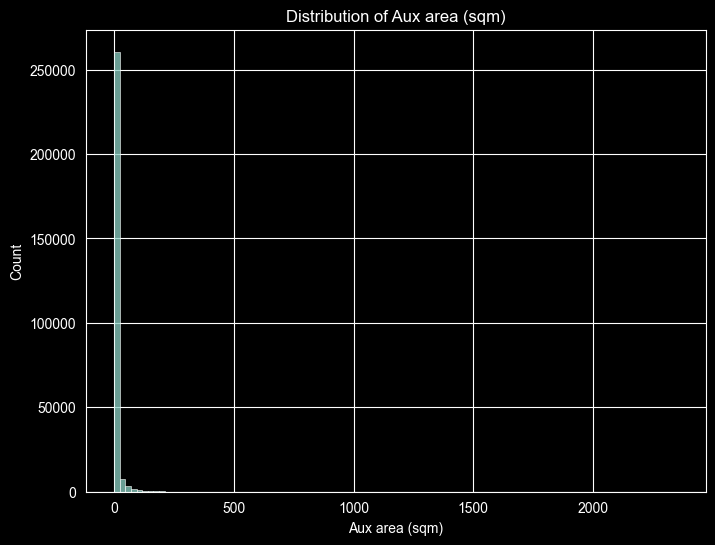

In [62]:
#Checking distribution of Column aux_area_sqm
#Right skewed Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['aux_area_sqm'], bins=100)
plt.title('Distribution of Aux area (sqm)')
plt.xlabel('Aux area (sqm)')
plt.ylabel('Count')
plt.show()

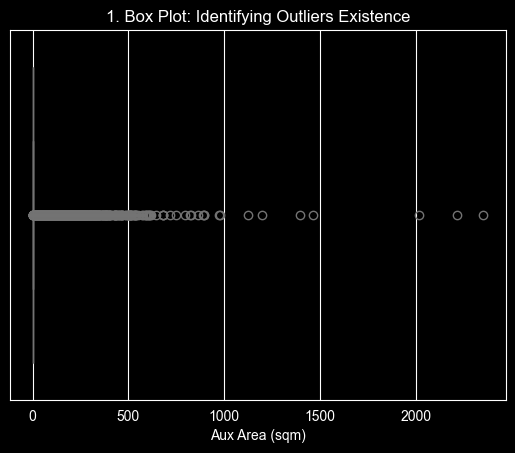

In [63]:
#Checking for Outliers Existance in Column aux_area_sqm
sns.boxplot(x=df['aux_area_sqm'], color='lightgreen')
plt.title('1. Box Plot: Identifying Outliers Existence')
plt.xlabel('Aux Area (sqm)')
plt.show()

In [64]:
#Implementing Log Transformation to column aux_area_sqm in a new Column log1p_aux_area_sqm
#Using np.log1p() to handle values that are set to 0
df['log1p_aux_area_sqm'] = np.log1p(df['aux_area_sqm']) 

#Checking Statistics for Column log1p_aux_area_sqm
print(df['log1p_aux_area_sqm'].describe().round(2))

#Visualizing the Before vs After the Log Transformation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plotting before Log Transformation aux_area_sqm
sns.histplot(df['aux_area_sqm'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Before: Log Transformed')

# Plotting after Log Transformation aux_area_sqm
sns.histplot(df['log1p_aux_area_sqm'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('After: Log Transformed')
plt.show()

# Checking the new skewness (It should be closer to 0)
print("Original Skewness:", df['aux_area_sqm'].skew().round(2))
print("Transformed Skewness:", df['log1p_aux_area_sqm'].skew().round(2))

Original Skewness: 21.99
Transformed Skewness: 2.1


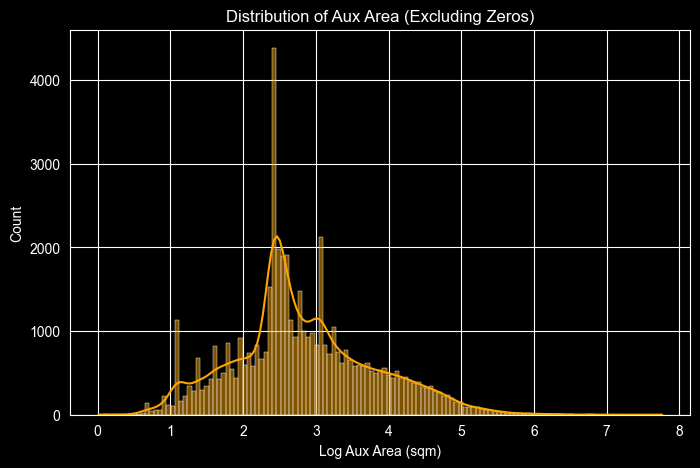

In [65]:
#Visualizing only the rows where df['has_aux_area']=0
#df['has_aux_area']=1 if Column aux_area_sqm originally had a value, df['has_aux_area']=0 if its value was NaN 

plt.figure(figsize=(8, 5))
sns.histplot(df[df['aux_area_sqm'] > 0]['log1p_aux_area_sqm'], kde=True, color='orange')
plt.title('Distribution of Aux Area (Excluding Zeros)')
plt.xlabel('Log Aux Area (sqm)')
plt.show()

In [66]:
#Implementing IQR method:

#Outliers:
#Condition 1: Must be > 0 (to ignore zeros)
#Condition 2: Their value must be outside the fences of IQR method

log1p_aux_area_sqm = df['log1p_aux_area_sqm']
col = 'log1p_aux_area_sqm'

positive_log1p_data = df[df[col] > 0][col]

#Splitting base_price values in percentiles 
Q1 = np.percentile(positive_log1p_data,25,method='midpoint')
Q2 = np.percentile(positive_log1p_data,50,method='midpoint')
Q3 = np.percentile(positive_log1p_data,75,method='midpoint')
IQR=Q3-Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

In [67]:
#Identifying Outliers
outliers_log1p_aux_area_sqm = df[(df[col] > 0) & ((df[col] < lower_fence) | (df[col] > upper_fence))]

#Viewing the Outliers
#outliers_log1p_aux_area_sqm

#Finding indices of Outliers
outliers_log1p_aux_area_sqm_indices = df[(df[col] > 0) & ((df[col] < lower_fence) | (df[col] > upper_fence))].index

print(f"Total rows in column: {len(df)}")
print(f"Number of zeros (Ignored): {len(df[df[col] == 0])}")
print(f"Number of outliers found (among non-zeros): {len(outliers_log1p_aux_area_sqm_indices)}")

Total rows in column: 276052
Number of zeros (Ignored): 224797
Number of outliers found (among non-zeros): 926


In [68]:
# Dropping identified outliers
print(f"Original shape before dropping outliers in column log_aux_area_sqm (zeros preserved): {df.shape}")
df = df.drop(outliers_log1p_aux_area_sqm_indices)
print(f"New shape after dropping outliers in column log_aux_area_sqm (zeros preserved): {df.shape}")

#Reseting index of DataFrame
df.reset_index(drop=True,inplace=True)
#df.head()

Original shape before dropping outliers in column log_aux_area_sqm (zeros preserved): (276052, 28)
New shape after dropping outliers in column log_aux_area_sqm (zeros preserved): (275126, 28)


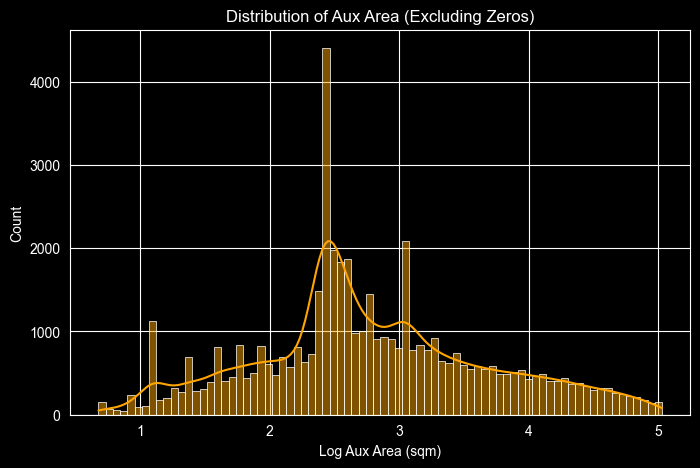

In [69]:
#Checking Statistics for Column log1p_aux_area_sqm
print(df['log1p_aux_area_sqm'].describe().round(2))

#Visualizing only the rows where df['has_aux_area']=0
#df['has_aux_area']=1 if Column aux_area_sqm originally had a value, df['has_aux_area']=0 if its value was NaN 

plt.figure(figsize=(8, 5))
sns.histplot(df[df['aux_area_sqm'] > 0]['log1p_aux_area_sqm'], kde=True, color='orange')
plt.title('Distribution of Aux Area (Excluding Zeros)')
plt.xlabel('Log Aux Area (sqm)')
plt.show()

#### Exploring Target Column price

In [70]:
#Understanding values in Target Column price
unique_price_count = df['price'].nunique()
print('The unique values in Target Column price are:',unique_price_count)
print(' ')

#Checking statistics of Target Column price
print(df['price'].describe())
print(' ')

print(df['price'].value_counts())
print(' ')

The unique values in Target Column price are: 89551
 
count    2.751260e+05
mean     7.448299e+04
std      1.490638e+06
min      0.000000e+00
25%      1.000000e+04
50%      3.000000e+04
75%      7.500000e+04
max      6.501000e+08
Name: price, dtype: float64
 
price
20000.00    6753
30000.00    6098
10000.00    5842
15000.00    5312
50000.00    5252
            ... 
2044.92        1
829.59         1
94170.41       1
4232.88        1
16291.81       1
Name: count, Length: 89551, dtype: int64
 


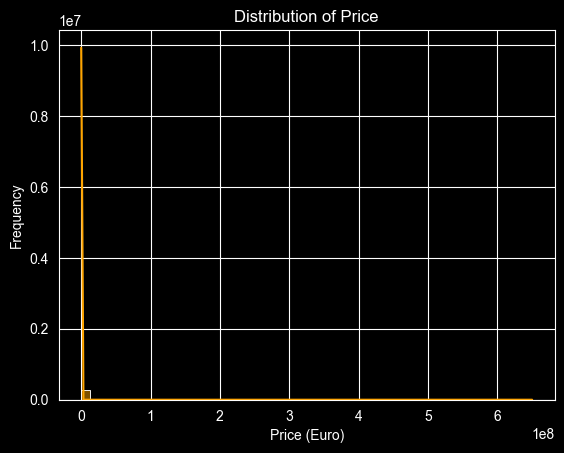

In [71]:
#Examining the Distribution of column price for prices >0
valid_prices = df[df['price'] > 0]['price']

sns.histplot(valid_prices, bins=50, kde=True, color='orange')
plt.title('Distribution of Price')
plt.xlabel('Price (Euro)')
plt.ylabel('Frequency')
plt.show()

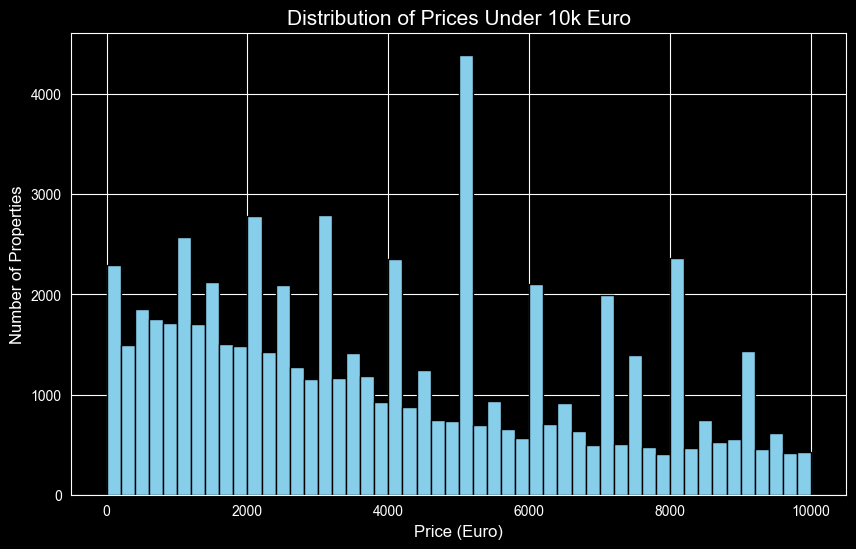

In [72]:
# Visualizing only prices under 10k to check the distribution
subset = df[df['price'] < 10000]['price']

plt.figure(figsize=(10, 6))
plt.hist(subset, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Prices Under 10k Euro", fontsize=15)
plt.xlabel("Price (Euro)", fontsize=12)
plt.ylabel("Number of Properties", fontsize=12)
plt.show()

In [73]:
# Visualizing only prices between 1k and 5k to check the distribution
low_value_df = df[(df['price'] >= 1000) & (df['price'] < 5000)]
print(f"Rows between €1,000 and €5,000: {len(low_value_df)}")

Rows between €1,000 and €5,000: 31582


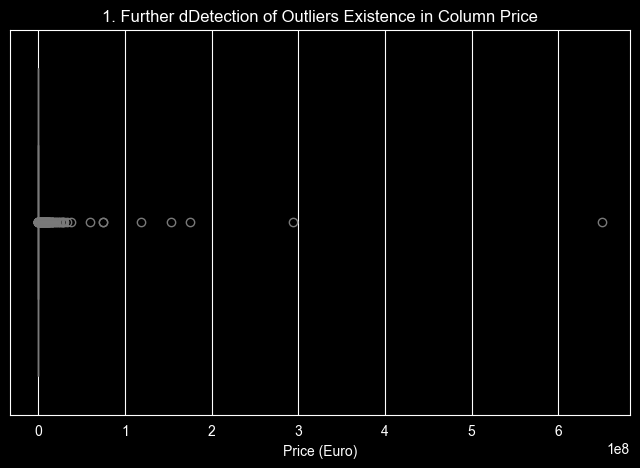

In [74]:
#Checking for other Outliers of column price & keeping only prices with value >0
valid_prices = df[df['price'] > 0]['price']
bad_price_rows = df[df['price'] <= 1000].shape[0] 
print(f"Dropping {bad_price_rows} rows with unrealistic prices for a house (<= €1000)...")
df = df[df['price'] > 1000].copy()
print(f"New Min Price: €{df['price'].min()}")
print(' ')

plt.figure(figsize=(8, 5))
sns.boxplot(x=valid_prices, color='lightblue')
plt.title('1. Further dDetection of Outliers Existence in Column Price')
plt.xlabel('Price (Euro)')
plt.show()

In [75]:
#Implementing Log Transformation to column price in a new Column log1p_price
#Using np.log1p() to handle 0 values if existing
df['log1p_price'] = np.log1p(df['price']) 

#Checking Statistics for Column log1p_price
print(df['log1p_price'].describe().round(2))

#Visualizing the Before vs After the Log Transformation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plotting before Log Transformation price
sns.histplot(df['price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Before: Log Transformed')

# Plotting after Log Transformation price
sns.histplot(df['log1p_price'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('After: Log Transformed')
plt.show()

# Checking the new skewness (It should be closer to 0)
print("Original Skewness:", df['price'].skew().round(2))
print("Transformed Skewness:", df['log1p_price'].skew().round(2))

Original Skewness: 336.14
Transformed Skewness: -0.19


In [76]:
#Implementing IQR method:
#Outliers:
#Condition 1: Must be > 0 (to ignore zeros)
#Condition 2: Their value must be outside the fences of IQR method

log1p_price = df['log1p_price']
col = 'log1p_price'

positive_log1p_price = df[df[col] > 0][col]

#Splitting base_price values in percentiles 
Q1 = np.percentile(positive_log1p_price,25,method='midpoint')
Q2 = np.percentile(positive_log1p_price,50,method='midpoint')
Q3 = np.percentile(positive_log1p_price,75,method='midpoint')
IQR=Q3-Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

In [77]:
#Identifying Outliers
outliers_log1p_price = df[(df[col] > 0) & ((df[col] < lower_fence) | (df[col] > upper_fence))]

#Viewing the Outliers
#outliers_log1p_price

#Finding indices of Outliers
outliers_log1p_price_indices = df[(df[col] > 0) & ((df[col] < lower_fence) | (df[col] > upper_fence))].index

print(f"Total rows in column: {len(df)}")
print(f"Number of zeros (Ignored): {len(df[df[col] == 0])}")
print(f"Number of outliers found (among non-zeros): {len(outliers_log1p_price_indices)}")

Total rows in column: 265042
Number of zeros (Ignored): 0
Number of outliers found (among non-zeros): 588


In [78]:
# Dropping identified outliers
print(f"Original shape before dropping outliers in column log1p_price (zeros preserved): {df.shape}")
df = df.drop(outliers_log1p_price_indices)
print(f"New shape after dropping outliers in column log1p_price (zeros preserved): {df.shape}")

#Reseting index of DataFrame
df.reset_index(drop=True,inplace=True)
#df.head()

Original shape before dropping outliers in column log1p_price (zeros preserved): (265042, 29)
New shape after dropping outliers in column log1p_price (zeros preserved): (264454, 29)


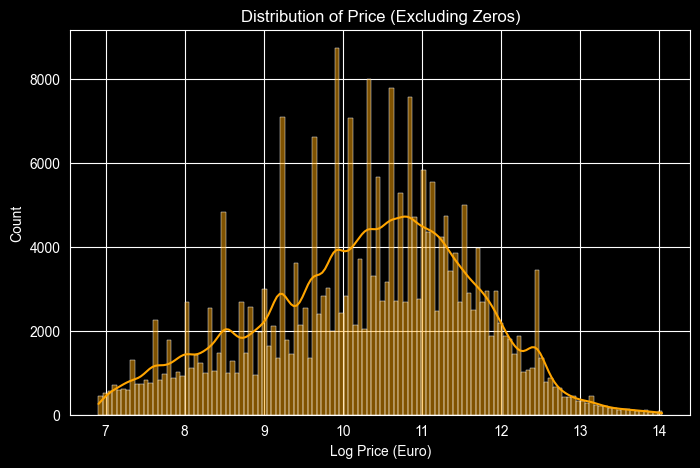

In [79]:
#Checking Statistics for Column log1p_aux_area_sqm
print(df['log1p_price'].describe().round(2))

#Visualizing only the rows where df['has_aux_area']=0
#df['has_aux_area']=1 if Column aux_area_sqm originally had a value, df['has_aux_area']=0 if its value was NaN 

plt.figure(figsize=(8, 5))
sns.histplot(df[df['price'] > 0]['log1p_price'], kde=True, color='orange')
plt.title('Distribution of Price (Excluding Zeros)')
plt.xlabel('Log Price (Euro)')
plt.show()

#### Preparation before Modeling

*Updating columns list with new columns added in EDA & with Feature Engineering*

In [80]:
#Updating the list for our Columns for Dataframe df
df_columns = list(df)
#Cleaning again Columns names in case they have any whitespace by mistake not visible
df.columns = df.columns.str.strip()
df_columns

['region',
 'city',
 'area',
 'apaa_flag',
 'property_type',
 'num_facades',
 'base_price',
 'main_area_sqm',
 'aux_area_sqm',
 'year_built',
 'building_right',
 'building_share',
 'conditions',
 'floor',
 'land_area',
 'land_right',
 'land_share',
 'total_building_area',
 'contract_year',
 'price',
 'base_price_tier',
 'log_base_price',
 'property_type_grouped',
 'building_age',
 'age_group',
 'log_main_area_sqm',
 'has_aux_area',
 'log1p_aux_area_sqm',
 'log1p_price']

*Converting Categorical Features to numerical*

In [81]:
#Checking number of Columns to add after One Hot Encoding is -1 from number of values of each category 
print(df['property_type_grouped'].value_counts())
print(' ')
print(df['base_price_tier'].value_counts())
print(' ')

property_type_grouped
Apartment                150182
Land_Plot                 39076
Detached_House            26989
Commercial_Industrial     20583
Storage_Agricultural      16638
Parking                   10327
Other                       659
Name: count, dtype: int64
 
base_price_tier
Medium       67335
Very Low     58404
Very High    51284
Low          46236
High         41195
Name: count, dtype: int64
 


In [82]:
# Applying One-Hot Encoding to convert categorical column property_type_grouped to numerical and drop property_type_Apartment
df = pd.get_dummies(df, columns=['property_type_grouped'], prefix='property_type', drop_first=False, dtype=int)
df = df.drop(columns=['property_type_Apartment'])

# Applying One-Hot Encoding to convert categorical column base_price_tier to numerical
df = pd.get_dummies(df, columns=['base_price_tier'], prefix='base_price', drop_first=True, dtype=int)

In [83]:
#Adding a new Column with Feature Engineering while testing model
df['Log_base_price_per_main_area_sqm']=df['log_base_price']-df['log_main_area_sqm']

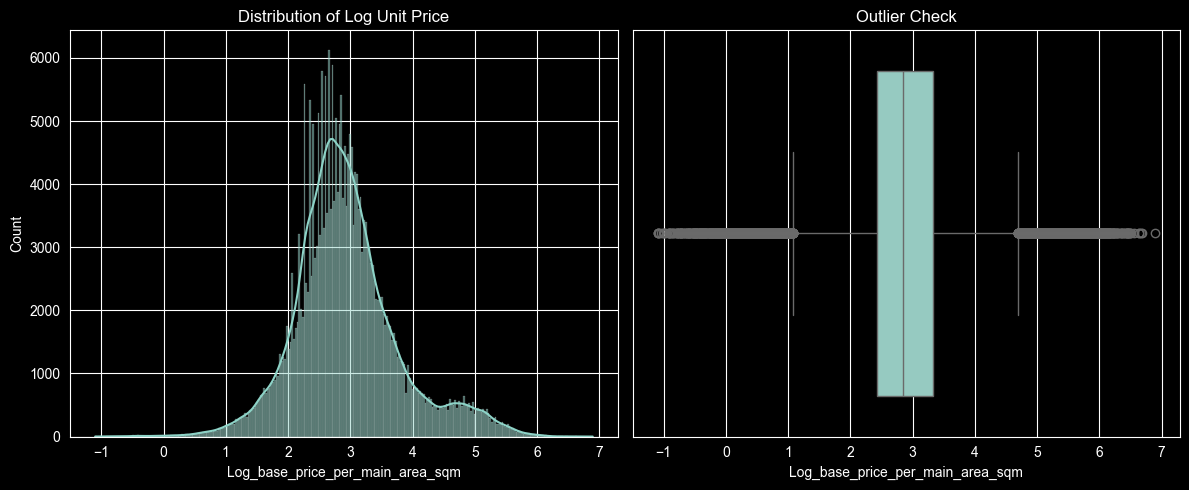

In [84]:
#Checking new Column Log_base_price_per_main_area_sqm Distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# With Histogram (Checking for Bell Curve=>Normal Distribution indicator)
sns.histplot(df['Log_base_price_per_main_area_sqm'], kde=True, ax=ax[0])
ax[0].set_title('Distribution of Log Unit Price')
# With Boxplot (Checking for Outliers)
sns.boxplot(x=df['Log_base_price_per_main_area_sqm'], ax=ax[1])
ax[1].set_title('Outlier Check')
plt.tight_layout()
plt.show()

In [85]:
#Implementing IQR for Column Log_base_price_per_main_area_sqm to detect extreme Outliers
Log_base_price_per_main_area_sqm = df['Log_base_price_per_main_area_sqm']

#Splitting base_price values in percentiles 
Q1 = np.percentile(Log_base_price_per_main_area_sqm,25,method='midpoint')
Q2 = np.percentile(Log_base_price_per_main_area_sqm,50,method='midpoint')
Q3 = np.percentile(Log_base_price_per_main_area_sqm,75,method='midpoint')

#Calculating the Interquartile Range
IQR=Q3-Q1

lower_fence = Q1 - 3 * IQR
upper_fence = Q3 + 3 * IQR

print('Column Log_base_price_per_main_area_sqm Outliers are:')
print(f"Lower Fence (Log): {lower_fence}")
print(f"Upper Fence (Log): {upper_fence}")

Column Log_base_price_per_main_area_sqm Outliers are:
Lower Fence (Log): -0.28229313944576084
Upper Fence (Log): 6.042349520781851


In [86]:
#Finding rows with outliers values in column Log_base_price_per_main_area_sqm
outliers_Log_base_price_per_main_area_sqm_df = df[(df['Log_base_price_per_main_area_sqm'] < lower_fence) | (df['Log_base_price_per_main_area_sqm'] > upper_fence)]
print("Number of outliers found:", outliers_Log_base_price_per_main_area_sqm_df.shape[0])
print(' ')

#Checking outliers of Log_base_price_per_main_area_sqm rows
#outliers_Log_base_price_per_main_area_sqm_df

Number of outliers found: 287
 


In [87]:
print('Initial DataFrame shape before removal of Extreme Outliers in column Log_base_price_per_main_area_sqm:')
print(df.shape)
print(' ')

#Dropping rows with extreme outliers spotted in column Log_base_price_per_main_area_sqm by their index
df = df.drop(outliers_Log_base_price_per_main_area_sqm_df.index)

print('Updated DataFrame shape after removal of Extreme Outliers in column Log_base_price_per_main_area_sqm:')
print(df.shape)
print(' ')

#Reseting index of DataFrame
df.reset_index(drop=True,inplace=True)
#df.head()

#Checking again Statistics for Column Log_base_price_per_main_area_sqm
print(df['Log_base_price_per_main_area_sqm'].describe().round(2))

Initial DataFrame shape before removal of Extreme Outliers in column Log_base_price_per_main_area_sqm:
(264454, 38)
 
Updated DataFrame shape after removal of Extreme Outliers in column Log_base_price_per_main_area_sqm:
(264167, 38)
 
count    264167.00
mean          2.94
std           0.83
min          -0.28
25%           2.43
50%           2.85
75%           3.33
max           6.04
Name: Log_base_price_per_main_area_sqm, dtype: float64


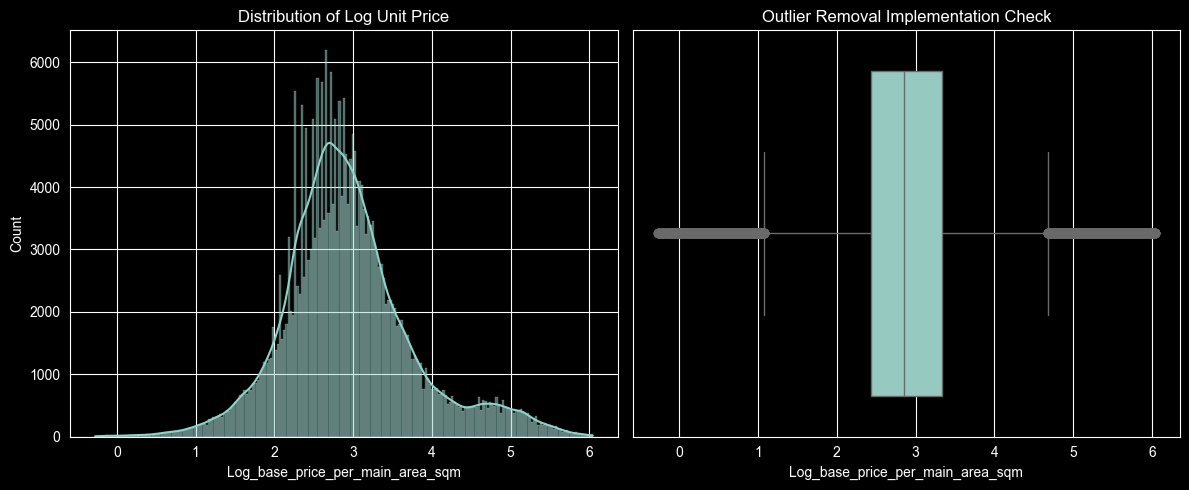

In [88]:
#Checking again Column Log_base_price_per_main_area_sqm Distribution after removal of Outliers
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# With Histogram (Checking for Bell Curve=>Normal Distribution indicator)
sns.histplot(df['Log_base_price_per_main_area_sqm'], kde=True, ax=ax[0])
ax[0].set_title('Distribution of Log Unit Price')
# With Boxplot (Checking for Outliers after the removal of already found ones with IQR method)
sns.boxplot(x=df['Log_base_price_per_main_area_sqm'], ax=ax[1])
ax[1].set_title('Outlier Removal Implementation Check')
plt.tight_layout()
plt.show()

In [89]:
#Adding a new Column with Feature Engineering while testing model
df['log_main_area_sqm_2'] = df['log_main_area_sqm'] ** 2

#Checking Statistics for Column log_main_area_sqm_2
print(df['log_main_area_sqm_2'].describe().round(2))

count    264167.00
mean         16.88
std           5.16
min           3.11
25%          14.61
50%          17.08
75%          19.67
max          41.27
Name: log_main_area_sqm_2, dtype: float64


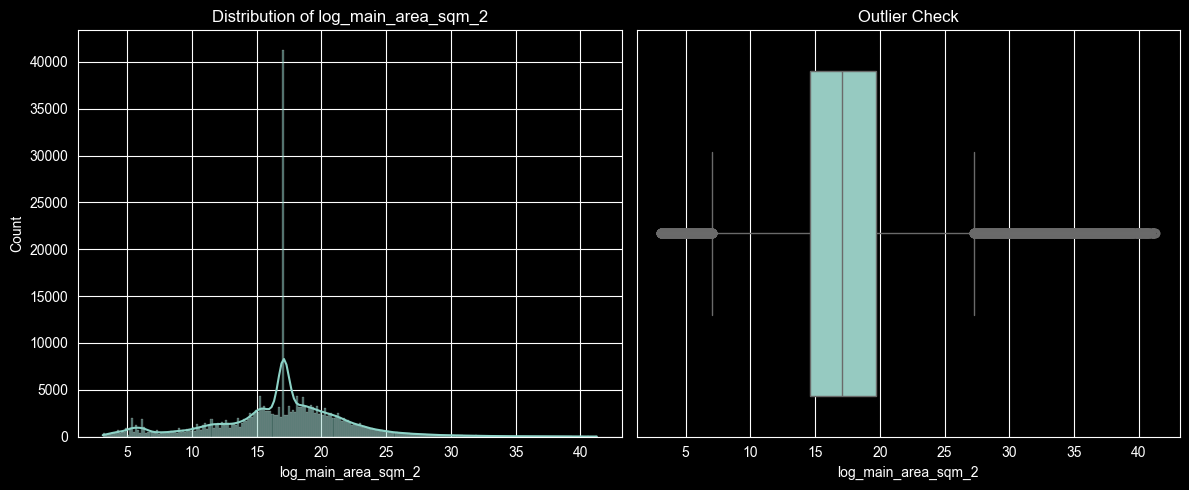

In [90]:
#Checking new Column log_main_area_sqm_2 Distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# With Histogram (Checking for Bell Curve=>Normal Distribution indicator)
sns.histplot(df['log_main_area_sqm_2'], kde=True, ax=ax[0])
ax[0].set_title('Distribution of log_main_area_sqm_2')
# With Boxplot (Checking for Outliers)
sns.boxplot(x=df['log_main_area_sqm_2'], ax=ax[1])
ax[1].set_title('Outlier Check')
plt.tight_layout()
plt.show()

In [91]:
#Implementing IQR for extreme outliers of Column log_main_area_sqm_2
log_main_area_sqm_2 = df['log_main_area_sqm_2']

#Splitting base_price values in percentiles 
Q1 = np.percentile(log_main_area_sqm_2,25,method='midpoint')
Q2 = np.percentile(log_main_area_sqm_2,50,method='midpoint')
Q3 = np.percentile(log_main_area_sqm_2,75,method='midpoint')

#Calculating the Interquartile Range
IQR=Q3-Q1

lower_fence = Q1 - 3 * IQR
upper_fence = Q3 + 3 * IQR

print('Column log_main_area_sqm_2 Outliers are:')
print(f"Lower Fence (Log): {lower_fence}")
print(f"Upper Fence (Log): {upper_fence}")

Column log_main_area_sqm_2 Outliers are:
Lower Fence (Log): -0.5437302605271057
Upper Fence (Log): 34.82302894301417


In [92]:
#Finding rows with outliers values in column log_main_area_sqm_2
outliers_log_main_area_sqm_2_df = df[(df['log_main_area_sqm_2'] < lower_fence) | (df['log_main_area_sqm_2'] > upper_fence)]
print("Number of outliers found:", outliers_log_main_area_sqm_2_df.shape[0])
print(' ')

#Checking outliers of log_main_area_sqm_2 rows
#outliers_log_main_area_sqm_2_df

Number of outliers found: 828
 


In [93]:
print('Initial DataFrame shape before removal of Extreme Outliers in column log_main_area_sqm_2:')
print(df.shape)
print(' ')

#Dropping rows with extreme outliers spotted in column log_main_area_sqm_2 by their index
df = df.drop(outliers_log_main_area_sqm_2_df.index)

print('Updated DataFrame shape after removal of Extreme Outliers in column log_main_area_sqm_2:')
print(df.shape)
print(' ')

#Reseting index of DataFrame
df.reset_index(drop=True,inplace=True)
#df.head()

#Checking again Statistics for Column log_main_area_sqm_2
print(df['log_main_area_sqm_2'].describe().round(2))

Initial DataFrame shape before removal of Extreme Outliers in column log_main_area_sqm_2:
(264167, 39)
 
Updated DataFrame shape after removal of Extreme Outliers in column log_main_area_sqm_2:
(263339, 39)
 
count    263339.00
mean         16.81
std           5.04
min           3.11
25%          14.59
50%          17.08
75%          19.63
max          34.82
Name: log_main_area_sqm_2, dtype: float64


In [94]:
#Adding a new Column with Feature Engineering while testing model
df['log_main_area_sqm_3'] = df['log_main_area_sqm'] ** 3

#Checking Statistics for Column log_main_area_sqm_2
print(df['log_main_area_sqm_3'].describe().round(2))

count    263339.00
mean         71.34
std          30.20
min           5.50
25%          55.74
50%          70.61
75%          86.99
max         205.47
Name: log_main_area_sqm_3, dtype: float64


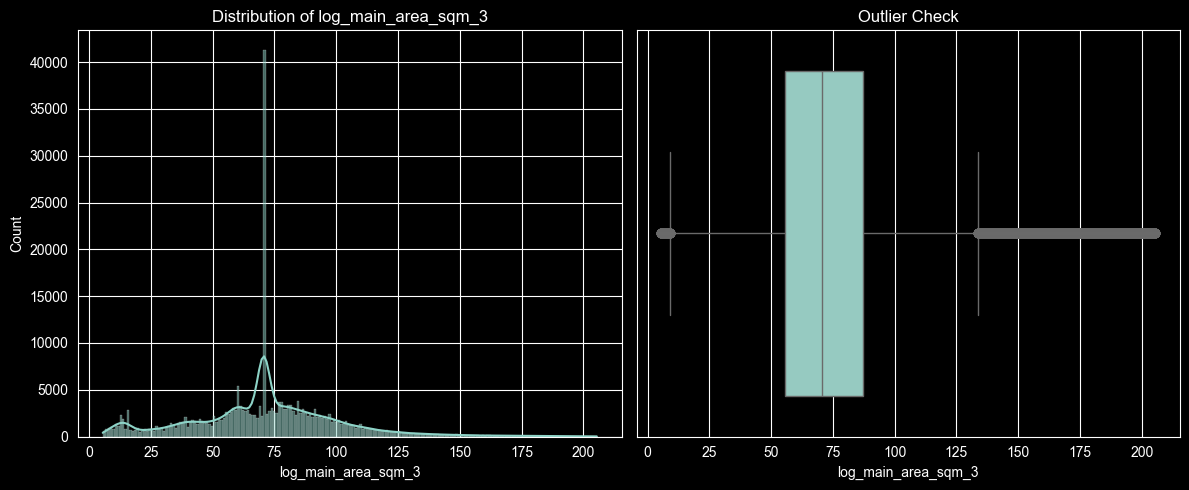

In [95]:
#Checking new Column log_main_area_sqm_3 Distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# With Histogram (Checking for Bell Curve=>Normal Distribution indicator)
sns.histplot(df['log_main_area_sqm_3'], kde=True, ax=ax[0])
ax[0].set_title('Distribution of log_main_area_sqm_3')
# With Boxplot (Checking for Outliers)
sns.boxplot(x=df['log_main_area_sqm_3'], ax=ax[1])
ax[1].set_title('Outlier Check')
plt.tight_layout()
plt.show()

In [96]:
#Implementing IQR for extreme outliers of Column log_main_area_sqm_3
log_main_area_sqm_3 = df['log_main_area_sqm_3']

#Splitting base_price values in percentiles 
Q1 = np.percentile(log_main_area_sqm_3,25,method='midpoint')
Q2 = np.percentile(log_main_area_sqm_3,50,method='midpoint')
Q3 = np.percentile(log_main_area_sqm_3,75,method='midpoint')

#Calculating the Interquartile Range
IQR=Q3-Q1

lower_fence = Q1 - 3 * IQR
upper_fence = Q3 + 3 * IQR

print('Column log_main_area_sqm_3 are:')
print(f"Lower Fence (Log): {lower_fence}")
print(f"Upper Fence (Log): {upper_fence}")

Column log_main_area_sqm_3 are:
Lower Fence (Log): -38.00350122090092
Upper Fence (Log): 180.72883406011692


In [97]:
#Finding rows with outliers values in column log_main_area_sqm_3
outliers_log_main_area_sqm_3_df = df[(df['log_main_area_sqm_3'] < lower_fence) | (df['log_main_area_sqm_3'] > upper_fence)]
print("Number of outliers found:", outliers_log_main_area_sqm_3_df.shape[0])
print(' ')

#Checking outliers of log_main_area_sqm_3 rows
#outliers_log_main_area_sqm_3_df

Number of outliers found: 1005
 


In [98]:
#print('Initial DataFrame shape before removal of Extreme Outliers in column log_main_area_sqm_3:')
#print(df.shape)
#print(' ')

#Dropping rows with extreme outliers spotted in column log_main_area_sqm_3 by their index
#df = df.drop(outliers_log_main_area_sqm_3_df.index)

#print('Updated DataFrame shape after removal of Extreme Outliers in column log_main_area_sqm_3:')
#print(df.shape)
#print(' ')

#Reseting index of DataFrame
#df.reset_index(drop=True,inplace=True)
#df.head()

#Checking again Statistics for Column log_main_area_sqm_3
#print(df['log_main_area_sqm_3'].describe().round(2))

In [99]:
#Adding a new Column with Feature Engineering while testing model
df['log_main_area_sqm_4'] = df['log_main_area_sqm'] ** 4

#Checking Statistics for Column log_main_area_sqm_2
print(df['log_main_area_sqm_4'].describe().round(2))

count    263339.00
mean        308.03
std         168.68
min           9.70
25%         212.92
50%         291.85
75%         385.42
max        1212.44
Name: log_main_area_sqm_4, dtype: float64


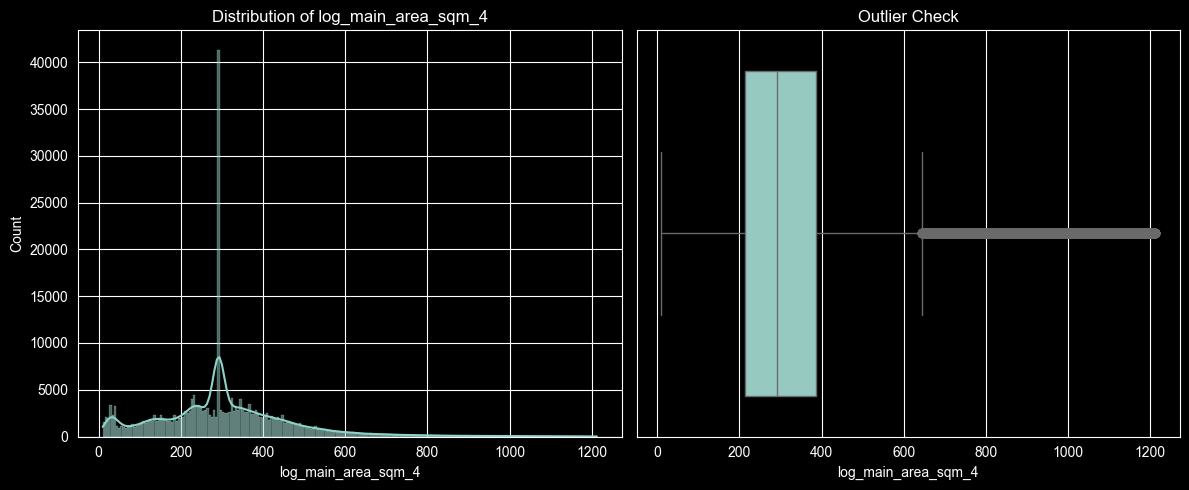

In [100]:
#Checking new Column log_main_area_sqm_4 Distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# With Histogram (Checking for Bell Curve=>Normal Distribution indicator)
sns.histplot(df['log_main_area_sqm_4'], kde=True, ax=ax[0])
ax[0].set_title('Distribution of log_main_area_sqm_4')
# With Boxplot (Checking for Outliers)
sns.boxplot(x=df['log_main_area_sqm_4'], ax=ax[1])
ax[1].set_title('Outlier Check')
plt.tight_layout()
plt.show()

In [101]:
#Implementing IQR for extreme outliers of Column log_main_area_sqm_3
log_main_area_sqm_4 = df['log_main_area_sqm_4']

#Splitting base_price values in percentiles 
Q1 = np.percentile(log_main_area_sqm_4,25,method='midpoint')
Q2 = np.percentile(log_main_area_sqm_4,50,method='midpoint')
Q3 = np.percentile(log_main_area_sqm_4,75,method='midpoint')

#Calculating the Interquartile Range
IQR=Q3-Q1

lower_fence = Q1 - 3 * IQR
upper_fence = Q3 + 3 * IQR

print('Column log_main_area_sqm_4 are:')
print(f"Lower Fence (Log): {lower_fence}")
print(f"Upper Fence (Log): {upper_fence}")

Column log_main_area_sqm_4 are:
Lower Fence (Log): -304.5922214936978
Upper Fence (Log): 902.9306063908823


In [102]:
#Finding rows with outliers values in column log_main_area_sqm_4
outliers_log_main_area_sqm_4_df = df[(df['log_main_area_sqm_4'] < lower_fence) | (df['log_main_area_sqm_4'] > upper_fence)]
print("Number of outliers found:", outliers_log_main_area_sqm_4_df.shape[0])
print(' ')

#Checking outliers of log_main_area_sqm_4 rows
#outliers_log_main_area_sqm_4_df

Number of outliers found: 2363
 


In [103]:
#print('Initial DataFrame shape before removal of Extreme Outliers in column log_main_area_sqm_4:')
#print(df.shape)
#print(' ')

#Dropping rows with extreme outliers spotted in column log_main_area_sqm_4 by their index
#df = df.drop(outliers_log_main_area_sqm_4_df.index)

#print('Updated DataFrame shape after removal of Extreme Outliers in column log_main_area_sqm_4:')
#print(df.shape)
#print(' ')

#Reseting index of DataFrame
#df.reset_index(drop=True,inplace=True)
#df.head()

#Checking again Statistics for Column log_main_area_sqm_4
#print(df['log_main_area_sqm_4'].describe().round(2))

In [104]:
#Adding a new Column with Feature Engineering while testing model
df['log1p_aux_area_sqm2'] = df['log1p_aux_area_sqm'] ** 2

#Checking Statistics for Column log1p_aux_area_sqm2
print(df['log1p_aux_area_sqm2'].describe().round(2))

count    263339.00
mean          1.56
std           4.00
min           0.00
25%           0.00
50%           0.00
75%           0.00
max          25.28
Name: log1p_aux_area_sqm2, dtype: float64


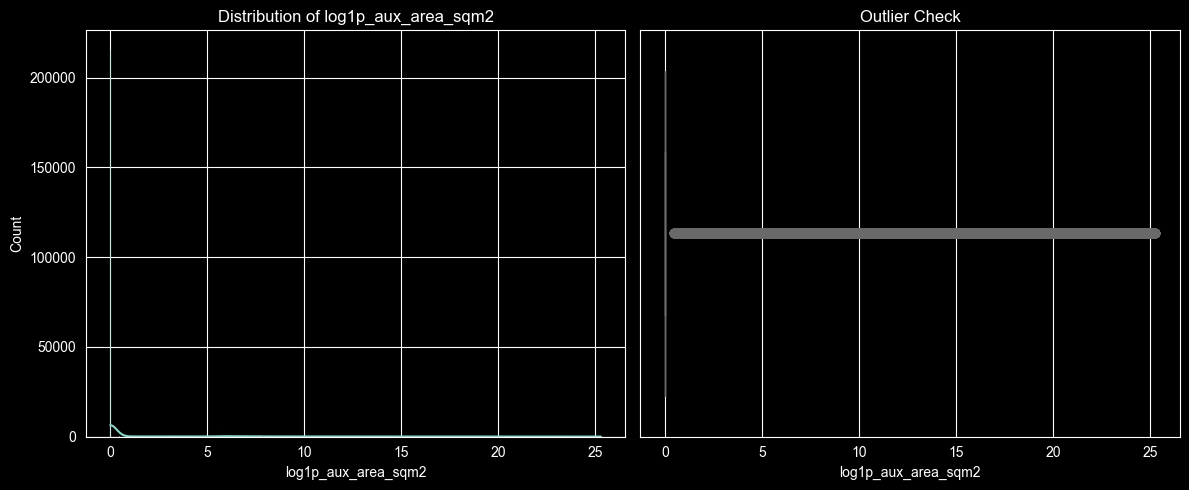

In [105]:
#Checking new Column log1p_aux_area_sqm2 Distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# With Histogram (Checking for Bell Curve=>Normal Distribution indicator)
sns.histplot(df['log1p_aux_area_sqm2'], kde=True, ax=ax[0])
ax[0].set_title('Distribution of log1p_aux_area_sqm2')
# With Boxplot (Checking for Outliers)
sns.boxplot(x=df['log1p_aux_area_sqm2'], ax=ax[1])
ax[1].set_title('Outlier Check')
plt.tight_layout()
plt.show()

In [106]:
#Implementing IQR for extreme outliers of Column log1p_aux_area_sqm2
log1p_aux_area_sqm2 = df['log1p_aux_area_sqm2']

#Splitting base_price values in percentiles 
Q1 = np.percentile(log1p_aux_area_sqm2,25,method='midpoint')
Q2 = np.percentile(log1p_aux_area_sqm2,50,method='midpoint')
Q3 = np.percentile(log1p_aux_area_sqm2,75,method='midpoint')

#Calculating the Interquartile Range
IQR=Q3-Q1

lower_fence = Q1 - 3 * IQR
upper_fence = Q3 + 3 * IQR

print('Column log1p_aux_area_sqm2 Outliers are:')
print(f"Lower Fence (Log): {lower_fence}")
print(f"Upper Fence (Log): {upper_fence}")

Column log1p_aux_area_sqm2 Outliers are:
Lower Fence (Log): 0.0
Upper Fence (Log): 0.0


In [107]:
#Finding rows with outliers values in column log1p_aux_area_sqm2
#outliers_log1p_aux_area_sqm2_df = df[(df['log1p_aux_area_sqm2'] < lower_fence) | (df['log1p_aux_area_sqm2'] > upper_fence)]
#print("Number of outliers found:", outliers_log_main_area_sqm_4_df.shape[0])
#print(' ')

#Checking outliers of log1p_aux_area_sqm2 rows
#outliers_log1p_aux_area_sqm2_df

In [108]:
#print('Initial DataFrame shape before removal of Extreme Outliers in column log1p_aux_area_sqm2:')
#print(df.shape)
#print(' ')

#Dropping rows with extreme outliers spotted in column log1p_aux_area_sqm2 by their index
#df = df.drop(outliers_log1p_aux_area_sqm2_df.index)

#print('Updated DataFrame shape after removal of Extreme Outliers in column log1p_aux_area_sqm2:')
#print(df.shape)
#print(' ')

#Reseting index of DataFrame
#df.reset_index(drop=True,inplace=True)
#df.head()

#Checking again Statistics for Column log1p_aux_area_sqm2
#print(df['log1p_aux_area_sqm2'].describe().round(2))

In [109]:
#Adding a new Column with Feature Engineering while testing model
df['Log_base_price_per_main_area_sqm2'] = df['Log_base_price_per_main_area_sqm'] ** 2

#Checking Statistics for Column Log_base_price_per_main_area_sqm2
print(df['Log_base_price_per_main_area_sqm2'].describe().round(2))

count    263339.00
mean          9.37
std           5.44
min           0.00
25%           5.93
50%           8.14
75%          11.10
max          36.50
Name: Log_base_price_per_main_area_sqm2, dtype: float64


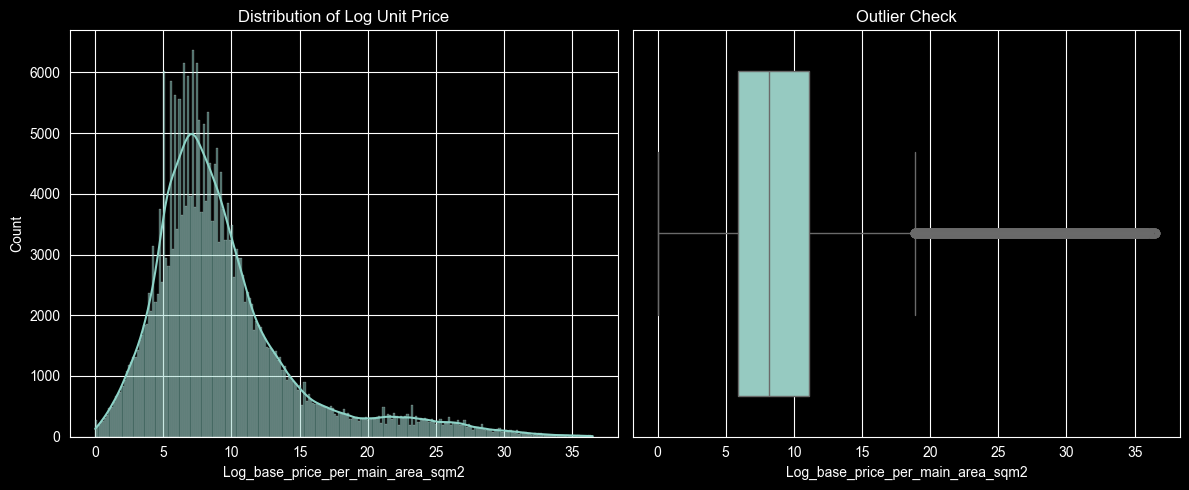

In [110]:
#Checking new Column Log_base_price_per_main_area_sqm2 Distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# With Histogram (Checking for Bell Curve=>Normal Distribution indicator)
sns.histplot(df['Log_base_price_per_main_area_sqm2'], kde=True, ax=ax[0])
ax[0].set_title('Distribution of Log Unit Price')
# With Boxplot (Checking for Outliers)
sns.boxplot(x=df['Log_base_price_per_main_area_sqm2'], ax=ax[1])
ax[1].set_title('Outlier Check')
plt.tight_layout()
plt.show()

In [111]:
#Implementing IQR for extreme outliers of Column Log_base_price_per_main_area_sqm2
Log_base_price_per_main_area_sqm2 = df['Log_base_price_per_main_area_sqm2']

#Splitting base_price values in percentiles 
Q1 = np.percentile(Log_base_price_per_main_area_sqm2,25,method='midpoint')
Q2 = np.percentile(Log_base_price_per_main_area_sqm2,50,method='midpoint')
Q3 = np.percentile(Log_base_price_per_main_area_sqm2,75,method='midpoint')

#Calculating the Interquartile Range
IQR=Q3-Q1

lower_fence = Q1 - 3 * IQR
upper_fence = Q3 + 3 * IQR

print('Column Log_base_price_per_main_area_sqm2 Outliers are:')
print(f"Lower Fence (Log): {lower_fence}")
print(f"Upper Fence (Log): {upper_fence}")

Column Log_base_price_per_main_area_sqm2 Outliers are:
Lower Fence (Log): -9.598596704762286
Upper Fence (Log): 26.630224599427663


In [112]:
#Finding rows with outliers values in column Log_base_price_per_main_area_sqm2
outliers_Log_base_price_per_main_area_sqm2_df = df[(df['Log_base_price_per_main_area_sqm2'] < lower_fence) | (df['Log_base_price_per_main_area_sqm2'] > upper_fence)]
print("Number of outliers found:", outliers_Log_base_price_per_main_area_sqm2_df.shape[0])
print(' ')

#Checking outliers of Log_base_price_per_main_area_sqm2 rows
#outliers_Log_base_price_per_main_area_sqm2_df

Number of outliers found: 4705
 


In [113]:
print('Initial DataFrame shape before removal of Extreme Outliers in column Log_base_price_per_main_area_sqm2:')
print(df.shape)
print(' ')

#Dropping rows with extreme outliers spotted in column Log_base_price_per_main_area_sqm2 by their index
df = df.drop(outliers_Log_base_price_per_main_area_sqm2_df.index)

print('Updated DataFrame shape after removal of Extreme Outliers in column Log_base_price_per_main_area_sqm2:')
print(df.shape)
print(' ')

#Reseting index of DataFrame
df.reset_index(drop=True,inplace=True)
#df.head()

#Checking again Statistics for Column Log_base_price_per_main_area_sqm2
print(df['Log_base_price_per_main_area_sqm2'].describe().round(2))

Initial DataFrame shape before removal of Extreme Outliers in column Log_base_price_per_main_area_sqm2:
(263339, 43)
 
Updated DataFrame shape after removal of Extreme Outliers in column Log_base_price_per_main_area_sqm2:
(258634, 43)
 
count    258634.00
mean          9.01
std           4.75
min           0.00
25%           5.87
50%           8.05
75%          10.88
max          26.63
Name: Log_base_price_per_main_area_sqm2, dtype: float64


In [114]:
#Adding a new Column with Feature Engineering while testing model. This feature's goal is to combines size and location quality
df['Interaction_Area_Location'] = df['log_main_area_sqm'] * df['Log_base_price_per_main_area_sqm']

#Checking Statistics for Column Interaction_Area_Location
print(df['Interaction_Area_Location'].describe().round(2))

count    258634.00
mean         11.45
std           1.98
min          -1.51
25%          10.47
50%          11.69
75%          12.65
max          18.95
Name: Interaction_Area_Location, dtype: float64


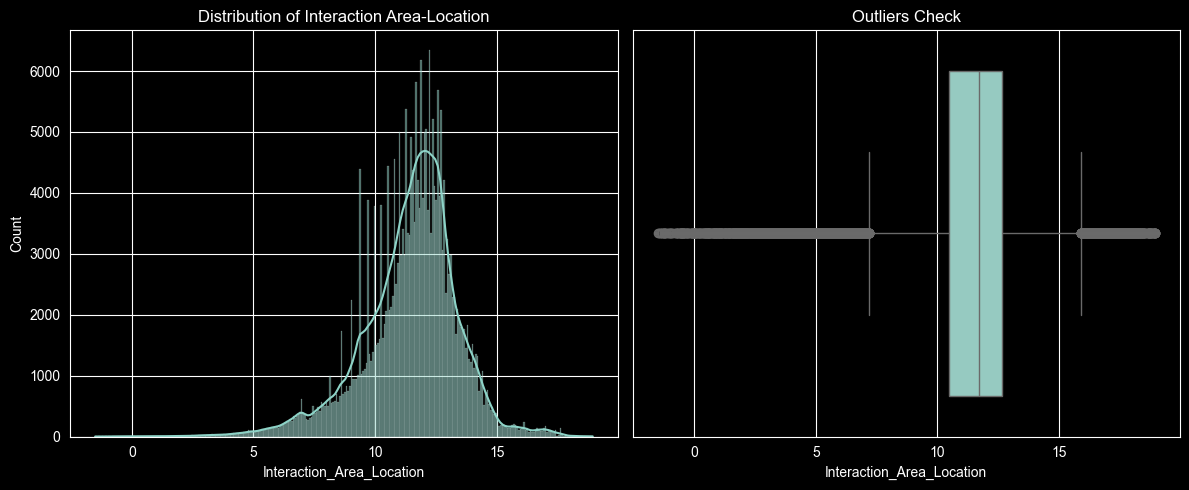

In [115]:
#Checking new Column Interaction_Area_Location Distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# With Histogram (Checking for Bell Curve=>Normal Distribution indicator)
sns.histplot(df['Interaction_Area_Location'], kde=True, ax=ax[0])
ax[0].set_title('Distribution of Interaction Area-Location')
# With Boxplot (Checking for Outliers)
sns.boxplot(x=df['Interaction_Area_Location'], ax=ax[1])
ax[1].set_title('Outliers Check')
plt.tight_layout()
plt.show()

In [116]:
#Implementing IQR for extreme outliers of Column Interaction_Area_Location
Interaction_Area_Location = df['Interaction_Area_Location']

#Splitting base_price values in percentiles 
Q1 = np.percentile(Interaction_Area_Location,25,method='midpoint')
Q2 = np.percentile(Interaction_Area_Location,50,method='midpoint')
Q3 = np.percentile(Interaction_Area_Location,75,method='midpoint')

#Calculating the Interquartile Range
IQR=Q3-Q1

lower_fence = Q1 - 3 * IQR
upper_fence = Q3 + 3 * IQR

print('Column Interaction_Area_Location Outliers are:')
print(f"Lower Fence (Log): {lower_fence}")
print(f"Upper Fence (Log): {upper_fence}")

Column Interaction_Area_Location Outliers are:
Lower Fence (Log): 3.936050163902051
Upper Fence (Log): 19.184230780512507


In [117]:
#Finding rows with outliers values in column Interaction_Area_Location
outliers_Interaction_Area_Location_df = df[(df['Interaction_Area_Location'] < lower_fence) | (df['Interaction_Area_Location'] > upper_fence)]
print("Number of outliers found:", outliers_Interaction_Area_Location_df.shape[0])
print(' ')

#Checking outliers of Interaction_Area_Location rows
#outliers_Interaction_Area_Location_df

Number of outliers found: 861
 


In [118]:
print('Initial DataFrame shape before removal of Extreme Outliers in column Interaction_Area_Location:')
print(df.shape)
print(' ')

#Dropping rows with extreme outliers spotted in column Interaction_Area_Location by their index
df = df.drop(outliers_Interaction_Area_Location_df.index)

print('Updated DataFrame shape after removal of Extreme Outliers in column Interaction_Area_Location:')
print(df.shape)
print(' ')

#Reseting index of DataFrame
df.reset_index(drop=True,inplace=True)
#df.head()

#Checking again Statistics for Column Interaction_Area_Location
print(df['Interaction_Area_Location'].describe().round(2))

Initial DataFrame shape before removal of Extreme Outliers in column Interaction_Area_Location:
(258634, 44)
 
Updated DataFrame shape after removal of Extreme Outliers in column Interaction_Area_Location:
(257773, 44)
 
count    257773.00
mean         11.48
std           1.91
min           3.94
25%          10.49
50%          11.70
75%          12.65
max          18.95
Name: Interaction_Area_Location, dtype: float64


In [119]:
#Adding a new Column with Feature Engineering while testing model that labels conditions in groups
#but before doing it handling 0s in column conditions as 'Standard' with logic that real estate agents write only conditions when
#things are negative (as disadvantages)

#print(df.conditions.value_counts())

conditions_mapping ={'Ημιτελές κτίσμα': 'Unfinished',
    'Διατηρητέο κτίσμα εφόσον έχει εκδοθεί η σχετική πράξη': 'Preserved',
    'Οικόπεδο το οποίο τελεί υπό αναγκαστική απαλλοτρίωση': 'Expropriation_Land',
    'Κτίσματα που τελούν υπό αναγκαστική απαλλοτρίωση': 'Expropriation_Bldg',
    'Οικόπεδο το οποίο δεν είναι οικοδομήσιμο και δεν μπορεί να τακτοποιηθεί': 'Not_Buildable_Fatal',
    'Οικόπεδο το οποίο δεν είναι οικοδομήσιμο αλλά μπορεί να τακτοποιηθεί': 'Not_Buildable_Fixable',
    'Δεσμευμένο ακίνητο λόγω αρχαιολογικής έρευνας': 'Archaeological'
    }

df['condition2'] = df['conditions'].map(conditions_mapping)

#Checking for NaNs 
NaNs_conditions2 = df['condition2'].isna().sum()
print(f"Rows with condition with NaN value: {NaNs_conditions2}")
print(' ')

#Filling NaNs with 'Standard' 
df['condition2'] = df['condition2'].fillna('Standard')

#Checking again for NaNs 
NaNs_conditions2 = (df['condition2'] == 0).sum()
print(f"Updated Rows with condition with NaN value: {NaNs_conditions2}")

# Applying One-Hot Encoding to convert categorical column condition2 to numerical & dropping Standard out to be the baseline of model
df = pd.get_dummies(df, columns=['condition2'], prefix='cond', dtype=int)
if 'cond_Standard' in df.columns:
    df = df.drop(columns=['cond_Standard'])
    
#print(df.filter(like='cond_').head())

Updated Rows with condition with NaN value: 0


In [120]:
#Adding a new Column with Feature Engineering while testing model that labels aging of properties in groups

#Checking NaNs in column year_built
print(df['year_built'].isna().sum())

zeros_construction_year = (df['year_built'] == 0).sum()
print(f'Rows with Year 0: {zeros_construction_year}')
print(' ')
df['is_Age_Unknown'] = (df['year_built'] == 0).astype(int)
#print(f'Imputing 0s of column year_built with Median Year')
df['year_built'] = df['year_built'].replace(0, df['year_built'].median())
print(' ')

df['is_Historic'] = (df['year_built'] < 1940).astype(int)
df['is_PostWar']  = ((df['year_built'] >= 1950) & (df['year_built'] <= 1990)).astype(int)
df['is_NewBuild'] = (df['year_built'] > 2010).astype(int)

#print(df[['year_built', 'is_Historic', 'is_PostWar', 'is_NewBuild']].head())

0
Rows with Year 0: 0
 
 


In [121]:
#Updating the list for our Columns for Dataframe df
df_columns = list(df)
#Cleaning again Columns names in case they have any whitespace by mistake not visible
df.columns = df.columns.str.strip()
#df_columns

#### Finalizing DataFrame for Modeling

In [122]:
#Final Columns for Model:

final_columns = [
    
    # Initially Numerical Features:
    'log1p_aux_area_sqm',
    #'log1p_aux_area_sqm2',
    'floor',  
    'log_main_area_sqm',
    'log_main_area_sqm_2',
    #'log_main_area_sqm_3',
    #'log_main_area_sqm_4',
    #'Log_base_price_per_main_area_sqm',
    'Interaction_Area_Location',
    #'Log_base_price_per_main_area_sqm2',
    #'log_base_price',
    #'has_aux_area',
    
    #Age Features
    'is_Historic' ,
    'is_NewBuild' ,
    'is_PostWar',
    #'building_age' ,
    #'year_built,
    #'age_group',

    # Condition2 Type One-Hot Encoded Features:
    #'cond_Expropriation_Bldg',
    'cond_Expropriation_Land','cond_Not_Buildable_Fatal',
    'cond_Not_Buildable_Fixable','cond_Archaeological','cond_Unfinished', 
    #'cond_Preserved',
    
    # Property Type One-Hot Encoded Features:
    'property_type_Commercial_Industrial','property_type_Detached_House','property_type_Land_Plot','property_type_Other',
    'property_type_Parking','property_type_Storage_Agricultural',
    
    # Base Price Tiers One-Hot Encoded Features: 
    #'base_price_Low','base_price_Medium','base_price_High','base_price_Very High',  
    
    # Target Column:
    'log1p_price'
    
    ]

#Creating the new final DataFrame for Model
df_final = df[final_columns].copy()

#Checking that all types of Columns are numerical in final DataFrame df_final
print(df_final.dtypes)
print(' ')

# Checking the initial shape of the final DataFrame for Modeling 
print(f"Final DataFrame Initial Shape is: {df_final.shape}")
print(' ')

#Checking in the final DataFrame for Modeling for duplicates
print(f'Final DataFrame duplicate rows are: {df_final.duplicated().sum()}')
print(' ')

#Checking for duplicate rows being fixed
print('Current duplicate rows are:')
print(df_final.duplicated().sum())
print(' ')

#Dropping duplicate data rows found before in final DataFrame df_final
print('Updated duplicate rows are:')
print(df_final.drop_duplicates(inplace=True))
print(' ')
print(f"Final DataFrame after cleaning duplicates Shape is: {df_final.shape}")
print(' ')

#Proactive check in the final DataFrame for Modeling for NaN values
print(f"Remaining NaNs values in final df_final: {df_final.isna().sum()}")
print(' ')

#Reseting index of DataFrame
df_final.reset_index(drop=True,inplace=True)

# Checking the shape of the final DataFrame for Modeling 
print(f"Final DataFrame final Shape: {df_final.shape}")

#Initial raw DataFrame Shape was found: (304206, 20)")
initial_df_rows = 304206
initial_df_cols = 20
diff = initial_df_rows - df_final.shape[0]
percent = (diff / initial_df_rows) * 100

#print(f"Initial Shape of df DataFrame is: ({initial_df_rows}, {initial_df_cols})")
#print(' ')
#print(f"Final Shape of Final DataFrame before Modeling is:   {df_final.shape}")
print(f"% Difference in shape: {diff} rows removed from Initial raw data starting DataFrame ({percent:.2f}%)")
#print(' ')
#print(df_final.head())

None
 
Final DataFrame after cleaning duplicates Shape is: (229186, 20)
 
Remaining NaNs values in final df_final: log1p_aux_area_sqm                     0
floor                                  0
log_main_area_sqm                      0
log_main_area_sqm_2                    0
Interaction_Area_Location              0
is_Historic                            0
is_NewBuild                            0
is_PostWar                             0
cond_Expropriation_Land                0
cond_Not_Buildable_Fatal               0
cond_Not_Buildable_Fixable             0
cond_Archaeological                    0
cond_Unfinished                        0
property_type_Commercial_Industrial    0
property_type_Detached_House           0
property_type_Land_Plot                0
property_type_Other                    0
property_type_Parking                  0
property_type_Storage_Agricultural     0
log1p_price                            0
dtype: int64
 
Final DataFrame final Shape: (229186, 20)
% Differ

#### Modeling

In [123]:
features = df_final.drop(columns=['log1p_price'])
target = df_final['log1p_price']

#Preparing Columns to Scale. Ones from One-Hot Encoding or Column-Flags with 0-1 values will not be scaled
cols_to_scale = ['log1p_aux_area_sqm','floor','Interaction_Area_Location',
                 'log_main_area_sqm','log_main_area_sqm_2'  
                ]
#'building_age'

In [124]:
cols = pd.concat([features, target], axis=1)
Correlation_matrix = cols.corr(numeric_only=True).round(3)
Correlation_matrix

,log1p_aux_area_sqm,floor,log_main_area_sqm,log_main_area_sqm_2,Interaction_Area_Location,is_Historic,is_NewBuild,is_PostWar,cond_Expropriation_Land,cond_Not_Buildable_Fatal,cond_Not_Buildable_Fixable,cond_Archaeological,cond_Unfinished,property_type_Commercial_Industrial,property_type_Detached_House,property_type_Land_Plot,property_type_Other,property_type_Parking,property_type_Storage_Agricultural,log1p_price
log1p_aux_area_sqm,1.000,-0.052,0.129,0.156,-0.169,0.055,0.136,-0.269,-0.018,-0.016,-0.015,-0.004,0.097,0.021,0.271,-0.130,-0.014,0.037,0.005,0.123
floor,-0.052,1.000,0.259,0.239,0.181,-0.078,-0.006,0.092,-0.007,-0.006,-0.006,-0.001,-0.024,-0.067,-0.189,-0.048,-0.036,-0.242,-0.266,0.344
log_main_area_sqm,0.129,0.259,1.000,0.991,-0.173,0.032,0.014,0.073,0.004,0.003,0.003,0.003,0.022,-0.028,0.189,0.027,-0.025,-0.413,-0.322,0.567
log_main_area_sqm_2,0.156,0.239,0.991,1.000,-0.208,0.035,0.027,0.039,0.001,0.001,0.001,0.002,0.035,-0.020,0.200,0.005,-0.025,-0.371,-0.282,0.557
Interaction_Area_Location,-0.169,0.181,-0.173,-0.208,1.000,-0.092,-0.065,0.209,-0.006,0.004,-0.009,-0.001,-0.074,0.055,-0.348,-0.041,-0.058,0.029,-0.134,0.237
is_Historic,0.055,-0.078,0.032,0.035,-0.092,1.000,-0.048,-0.245,-0.007,-0.006,-0.005,0.007,-0.003,0.007,0.217,-0.050,0.005,-0.034,0.031,-0.041
is_NewBuild,0.136,-0.006,0.014,0.027,-0.065,-0.048,1.000,-0.373,-0.011,-0.009,-0.008,-0.002,0.314,-0.015,0.024,-0.075,0.055,0.027,0.034,0.096
is_PostWar,-0.269,0.092,0.073,0.039,0.209,-0.245,-0.373,1.000,0.028,0.025,0.022,0.003,-0.228,0.030,-0.093,0.202,-0.054,-0.216,-0.106,-0.027
cond_Expropriation_Land,-0.018,-0.007,0.004,0.001,-0.006,-0.007,-0.011,0.028,1.000,-0.001,-0.001,-0.000,-0.008,-0.012,-0.014,0.140,-0.002,-0.008,-0.010,-0.007
cond_Not_Buildable_Fatal,-0.016,-0.006,0.003,0.001,0.004,-0.006,-0.009,0.025,-0.001,1.000,-0.001,-0.000,-0.007,-0.011,-0.013,0.125,-0.002,-0.007,-0.009,-0.041


*Linear Regression Cross Validation Model*

In [125]:
# Data
X = features
y = target

# Initial Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

#Resetting indexes for K-Fold
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

#Implementing KFold Validation
kf = KFold(n_splits=5, shuffle=True, random_state=43)

# Lists to store metrics
cv_lm_r2s = []       # R2
cv_lm_mae = []       # Log MAE
cv_lm_mse = []       # Log MAE
cv_real_mae = []     # Real Money MAE (Euros)
cv_real_mse = []     # Real Money MSE (Euros)
cv_mape = []         # Percentage Error (%)

for train_ind, val_ind in kf.split(X_train, y_train):
    # Subset Data
    X_fold_train = X_train.iloc[train_ind].copy()
    y_fold_train = y_train.iloc[train_ind]
    X_fold_val = X_train.iloc[val_ind].copy()
    y_fold_val = y_train.iloc[val_ind]
    
    # Starting scaling specific columns only (cols_to_scale)
    scaler = StandardScaler()
    X_fold_train[cols_to_scale] = scaler.fit_transform(X_fold_train[cols_to_scale])
    X_fold_val[cols_to_scale] = scaler.transform(X_fold_val[cols_to_scale])

    # Adding Constant(=intercept column of 1s) after scaling
    X_fold_train_const = sm.add_constant(X_fold_train)
    X_fold_val_const = sm.add_constant(X_fold_val, has_constant='add')
    
    # Fitting the Model
    model_fold = sm.OLS(y_fold_train, X_fold_train_const).fit()
    
    # Predicting (Log Scale)
    val_preds_log = model_fold.predict(X_fold_val_const)
    
    # Calculating Log Metrics
    cv_lm_r2s.append(r2_score(y_fold_val, val_preds_log))
    cv_lm_mae.append(mean_absolute_error(y_fold_val, val_preds_log))
    cv_lm_mse.append(mean_squared_error(y_fold_val, val_preds_log))

    # Transforming numbers to real world metrics
    # Implementing inverse log with expm1 to get real prices
    real_preds = np.expm1(val_preds_log)
    real_y = np.expm1(y_fold_val)
    
    # Calculating the difference in Euros
    diff = np.abs(real_y - real_preds)
    
    # Calculating the real MAE (Average Error in Euros) & MSE(Mean Squared Error in Euros)
    cv_real_mae.append(np.mean(diff))
    cv_real_mse.append(np.mean(diff ** 2))
    
    # Calculating the MAPE (Average Percentage Error) with avoiding division by zero if any price is 0
    fold_mape = np.mean(diff / (real_y + 1e-9)) * 100
    cv_mape.append(fold_mape)

# Reporting
print(' ')
print('Log Scale Metrics (Model View)')
print('-'*35)
print(f'Average R2:{np.mean(cv_lm_r2s):.3f}')
print(f'Average Log MAE:{np.mean(cv_lm_mae):.3f}')
print(f'Average Log MSE:{np.mean(cv_lm_mse):.3f}')
print(' ')
print('Real World Metrics (Business View)')
print('-'*35)
print(f'Average Error (MAE): €{np.mean(cv_real_mae):,.0f}')
# Adding RMSE for better clarity
print(f'Avg Deviation (RMSE): €{np.sqrt(np.mean(cv_real_mse)):,.0f}') 
print(f'Average MAPE:{np.mean(cv_mape):.2f}%')
print(' ')

 
Log Scale Metrics (Model View)
-----------------------------------
Average R2:0.513
Average Log MAE:0.698
Average Log MSE:0.860
 
Real World Metrics (Business View)
-----------------------------------
Average Error (MAE): €37,131
Avg Deviation (RMSE): €79,525
Average MAPE:110.66%
 


*Linear Regression Cross Validation Model Fit on All Training Data*

In [126]:
# Initializing a NEW scaler for the final model
scaler_final = StandardScaler()

# Fitting on the FULL X_train this time
# Using .loc to only scale the cols_to_scale Columns
X_train.loc[:, cols_to_scale] = scaler_final.fit_transform(X_train[cols_to_scale])
# Transforming X_test (using the rules learned from X_train)
X_test.loc[:, cols_to_scale]  = scaler_final.transform(X_test[cols_to_scale])
# Adding Constant(=intercept column of 1s) after scaling
X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test, has_constant='add')
# Training the Final Linear Model which learns from 80% of data at once
final_model = sm.OLS(y_train, X_train_const).fit()

# Evaluating on the Hold-Out Test Set
# Predicting (Log Scale)
test_preds_log = final_model.predict(X_test_const)
# Transforming numbers to real world metrics
# Implementing inverse log with expm1 to get real prices
real_test_preds = np.expm1(test_preds_log)
real_y_test = np.expm1(y_test)

# Model View Metrics
log_r2 = r2_score(y_test, test_preds_log)
log_mae = mean_absolute_error(y_test, test_preds_log)
log_mse = mean_squared_error(y_test, test_preds_log)

# Business View Metrics
diff = np.abs(real_y_test - real_test_preds)
test_mae = np.mean(diff)
test_mse_real = mean_squared_error(real_y_test, real_test_preds)
test_rmse_real = np.sqrt(test_mse_real)
test_mape = np.mean(diff / (real_y_test + 1e-9)) * 100

# Final Reporting
print("-" * 40)
print("Final Model Perfomance (Test Set)")
print("-" * 40)
print("Model View (Log Scale)")
print(f"Test R2 Score:{r2_score(y_test, test_preds_log):.3f}")
print(f"Test Log MAE:{mean_absolute_error(y_test, test_preds_log):.3f}")
print(f"Test Log MSE:{mean_squared_error(y_test, test_preds_log):.3f}")    
print("-" * 40)
print("Business View (Real Prices)")
print(f"Test Average Error (MAE): €{test_mae:,.0f}")
print(f"Test RMSE (Avg Deviation): €{test_rmse_real:,.0f}") 
print(f"Test MAPE: {test_mape:.2f}%")
print("-" * 40)

#the Intercept represents the predicted price of a "Standard" property when all other flags are zero

----------------------------------------
Final Model Perfomance (Test Set)
----------------------------------------
Model View (Log Scale)
Test R2 Score:0.508
Test Log MAE:0.701
Test Log MSE:0.871
----------------------------------------
Business View (Real Prices)
Test Average Error (MAE): €37,393
Test RMSE (Avg Deviation): €81,466
Test MAPE: 111.66%
----------------------------------------


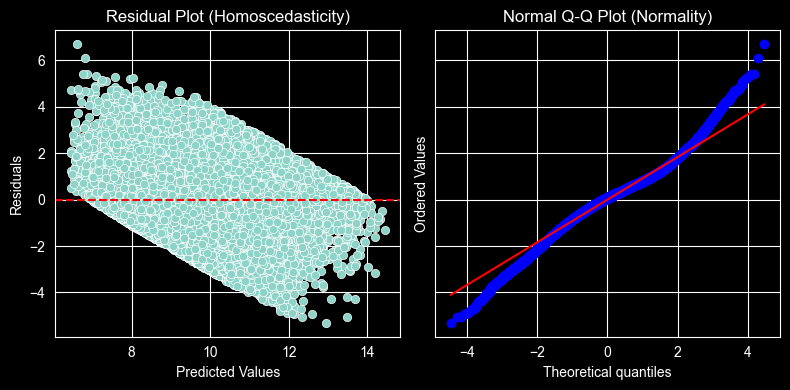

In [127]:
#Equal variance of Errors Check
#Function for Residual Plot and a Q-Q Plot for a statsmodels OLS model

def residual_analysis_plots(model):
    """
    Function generates a Residual Plot and a Q-Q Plot for a statsmodels OLS model.
    """
    #Getting predictions and residuals
    predictions = model.predict()
    residuals = model.resid  
    
    fig, ax = plt.subplots(1, 2, sharey='all', figsize=(8, 4)) 
    #Plot 1: Residual Plot (Homoscedasticity check)
    sns.scatterplot(x=predictions, y=residuals, ax=ax[0])
    #Adding a horizontal line at 0
    ax[0].axhline(y=0, color='r', linestyle='--') 
    ax[0].set_title('Residual Plot (Homoscedasticity)')
    ax[0].set_xlabel('Predicted Values')
    ax[0].set_ylabel('Residuals')
    
    #Plot 2: Normal Q-Q Plot (Normality check)
    stats.probplot(residuals, dist='norm', plot=ax[1])
    ax[1].set_title('Normal Q-Q Plot (Normality)')
    
    plt.tight_layout()
    plt.show()

residual_analysis_plots(final_model)

In [128]:
#Checking Multicollinearity
pd.Series([vfi(X.values,i) for i in range(X.shape[1])],index=X.columns)

#vfi>5 only to columns related that is expected to be so.

log1p_aux_area_sqm                       1.455549
floor                                    2.124908
log_main_area_sqm                      349.634771
log_main_area_sqm_2                    169.641026
Interaction_Area_Location               48.649298
is_Historic                              1.192323
is_NewBuild                              1.371465
is_PostWar                               4.466643
cond_Expropriation_Land                  1.022257
cond_Not_Buildable_Fatal                 1.017966
cond_Not_Buildable_Fixable               1.014178
cond_Archaeological                      1.000549
cond_Unfinished                          1.185510
property_type_Commercial_Industrial      1.163757
property_type_Detached_House             1.579723
property_type_Land_Plot                  1.258537
property_type_Other                      1.017813
property_type_Parking                    1.335632
property_type_Storage_Agricultural       1.275446
dtype: float64

In [129]:
#Checking Indipendence of Errors with Durbin-Watson & Coefficients/Feature Importance for Target Column:
#Durbin-Watson result: 1.994  => OK in acceptable range -> 1500 <= 1.994 <= 2500 
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:            log1p_price   R-squared:                       0.513
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                 1.017e+04
Date:                Sat, 31 Jan 2026   Prob (F-statistic):               0.00
Time:                        02:57:03   Log-Likelihood:            -2.4627e+05
No. Observations:              183348   AIC:                         4.926e+05
Df Residuals:                  183328   BIC:                         4.928e+05
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

In [130]:
#Checking Outliers with Cook's Distance method
#influence = final_model.get_influence() 
#inf_summary_df = influence.summary_frame().round(4)

#inf_summary_df.head(10)

#### Final Model Verdict & Business Insights

- R-squared: of 0.513 indicates that model explains approx 51.3% of the variance in the log-transformed target column 'price'.
  
- Sample Size: With 183348 observations, the results are statistically robust.
  
- Durbin-Watson: of 1.998 within the acceptable range => 1.500 <= 1.994 <= 2.500, meaning model does not have an issue with Indipendence of Errors

- In terms of Multicollinearity we are ok as vfi<5 for most columns. Only columns with vfi>5 are log_main_area_sqm, log_main_area_sqm_2 & Interaction_Area_Location that are related and we expect them to have vfi>5 due to that. Since they are adding value to the model it was decided to keep all three of them in the model.

- log_main_area_sqm & log_main_area_sqm_2 : Model is trying to describe a curved relationship using these two different variables that are actually partners and when viewing a negative number for log_main_area_sqm and a positive number for log_main_area_sqm_2 it means in reality that the relationship between size and price isn't a straight line. More specifically, the combination of linear and quadratic main area sqm terms proves that the price is not constant, but accelerates as the size of the property increases.

- The Intercept bo represents the predicted price of a "Standard" property when all other flags are zero

- In general because the target column 'price' is log-transformed, a coefficient of b for a continuous variable means a one-unit increase in that variable is associated with a (e^b-1)*100% change in price.

- In general we had also to log-transform features (apart from target Column) & even raise to power of some features to make sense of data.
This is the reason why a Ridge/Lasso approach would not help a lot developping the model results.

- More important positive correlations to target column we see from columns Interaction_Area_Location (coef: 0.4761), is_NewBuild (coef: 0.2600), and floor (coef: 0.1276).

- More important negative correlations to target column we see from columns cond_Not_Buildable_Fatal (coef: -1.3775), property_type_Parking (coef: -1.0005), and property_type_Storage_Agricultural (coef: -0.9287).

- Property_type_Parking & property_type_Storage_Agricultural appear to have massive negative coefficients (-1.0005 and -0.9287), suggesting these are valued significantly lower than the baseline property type, which is logical if we compare price of a house vs price of a parking or an Agricultural storage that would be located out of city most possibly, therefore price would be much cheaper.The % of negative effect that each column has to target column in real money is found by the equation: [(e^coefficient)-1]*100

- Historical Status: is_Historic appear to have a negative coefficient of -0.4233, indicating that they are predicted to be much cheaper than non-historic ones. The negative effect of coefficient of is_Historic column to target column sounds logical.The % of negative effect that is_Historic column has to target column in real money is found by the equation: [(e^-0.4233)-1]*100
     
- New Builds: is_NewBuild adds a positive infuence to target column 'price' (coefficient=0.26). The positive effect of coefficient of is_NewBuild column to target column sounds logical.The % of positive effect that is_NewBuild column has to target column in real money is found by the equation: [(e^0.26)-1]*100

- Floor: A one-unit increase in floor is associated with increasing the target column 'price' (coefficient=0.1276). The positive effect of coefficient of floor column to target column sounds logical.The % of positive effect that floor column has to target column in real money is found by the equation: [(e^0.1276)-1]*100

- The variance of errors spread in the model is unequal. We can understand the Heteroscedasticity from the Residual (Homoscedasticity) plot. Model appears to under-predict at the lower end and over-predict at the higher end of the price

- Normal Q-Q Plot (Non-Normal Residuals): There is no good Linearity in model, even after the Feature Engineering done. Model appears to make extreme mistakes (outliers) than a normal distribution. The high Kurtosis in the model summary of OLS method which is found 4.478 confirms this "peaked" error distribution.

- Final Model Verdict : Model is "safe" for "standard" apartments or houses but struggles with high-accuracy predictions for the very cheapest or most expensive luxury homes (=extreme model outliers)